**שלב 1: טעינה חכמה ושמירה על המזהים המקוריים (IDs)**


בשלב זה נטען את הנתונים, נוודא שהתאריכים תקינים, ונוודא שאנחנו שומרים את ה-_id של כל שורה (גם של שאלון PANAS וגם של דיווח ה-EMA).

In [18]:
from pathlib import Path
import pandas as pd
import numpy as np
from pathlib import Path

current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == "notebooks" else current_dir
DATA_DIR = PROJECT_ROOT / "data" / "processed_parquet"

# בדיקה שהתיקייה אכן קיימת במחשב של המשתמשת
if not DATA_DIR.exists():
    raise FileNotFoundError(f"⚠️ התיקייה לא נמצאה בנתיב: {DATA_DIR}\nאנא ודאי שמבנה התיקיות בפרויקט תואם.")
else:
    print(f"✅ נתיב הנתונים נקלט בהצלחה: {DATA_DIR}")

✅ נתיב הנתונים נקלט בהצלחה: c:\Users\naama\OneDrive\תמונות\שולחן העבודה\שנה ב\life_snap\lifesnaps_project\data\processed_parquet


In [19]:
panas_raw = pd.read_parquet(DATA_DIR / "panas.parquet")
sema_raw = pd.read_parquet(DATA_DIR / "all_sema_emotions.parquet")

# 1.A. הכנת טבלת הבסיס ל-PANAS
panas_base = panas_raw.copy()
# יצירת המזהה המקורי לשאלון - נמנע משגיאת חוסר בעמודה (KeyError)
if '_id' in panas_base.columns:
    panas_base['panas_original_id'] = panas_base['_id'].astype(str)
elif 'id' in panas_base.columns and panas_base['id'].nunique() == len(panas_base): 
    panas_base['panas_original_id'] = panas_base['id'].astype(str)
else:
    panas_base['panas_original_id'] = ["panas_" + str(i) for i in range(len(panas_base))]

panas_user_col = next((col for col in ['user_id', 'participant_id', 'id'] if col in panas_base.columns), None)
panas_base['user_id'] = panas_base[panas_user_col].astype(str).str.strip()
panas_date_col = 'submitdate' if 'submitdate' in panas_base.columns else 'date'
panas_base['panas_date'] = pd.to_datetime(panas_base[panas_date_col], errors='coerce').dt.normalize()

# סינון שאלונים ריקים וחישוב פער ימים (ישמש את שתי הגישות)
panas_base = panas_base.dropna(subset=['panas_original_id', 'user_id', 'panas_date', 'positive_affect_score', 'negative_affect_score']).copy()
panas_base = panas_base.sort_values(by=['user_id', 'panas_date']).reset_index(drop=True)
panas_base['days_since_last_panas'] = panas_base.groupby('user_id')['panas_date'].diff().dt.days


# 1.B. הכנת טבלת הבסיס ל-EMA
ema_base = sema_raw.copy()
if '_id' in ema_base.columns:
    ema_base['ema_original_id'] = ema_base['_id'].astype(str)
elif 'id' in ema_base.columns and ema_base['id'].nunique() == len(ema_base):
    ema_base['ema_original_id'] = ema_base['id'].astype(str)
else:
    ema_base['ema_original_id'] = ["ema_" + str(i) for i in range(len(ema_base))]

ema_user_col = next((col for col in ['participant_id', 'user_id', 'data.PARTICIPANT_ID'] if col in ema_base.columns), None)
ema_base['user_id'] = ema_base[ema_user_col].astype(str).str.strip()
sema_ts_col = 'data.COMPLETED_TS' if 'data.COMPLETED_TS' in ema_base.columns else 'timestamp'
ema_base['ema_timestamp'] = pd.to_datetime(ema_base[sema_ts_col], errors='coerce').dt.tz_localize(None)
ema_base['ema_date'] = ema_base['ema_timestamp'].dt.normalize()

# סינון דיווחים ריקים או ללא רגש תקין
ema_base = ema_base.dropna(subset=['ema_original_id', 'user_id', 'ema_date', 'data.MOOD']).copy()
ema_base = ema_base[ema_base['data.MOOD'] != '<no-response>']

print(f"✅ שלב 1 הושלם. נטענו {len(panas_base)} שאלוני PANAS ו-{len(ema_base)} דיווחי EMA.\n")



✅ שלב 1 הושלם. נטענו 268 שאלוני PANAS ו-5036 דיווחי EMA.



In [20]:
#** שלב 2: גישה א' - מסגרת זמן קבועה ונוקשה (Rigid 7-Days Window) **
#
#בגישה זו אנו הולכים תמיד 7 ימים אחורה. לאחר מכן נסנן את האלונים
# שיש בהם חפיפה או שחסרים בהם נתונים מספקים (נצפה ל-165 שאלונים נקיים בסוף).

טיפול בבעיות שהתגלו ב-Sanity Checks
ביקשת לחשוב מה עושים עם החפיפות.
המלצה שלי למודל אמין: אם לנבדק יש שני שאלוני PANAS בהפרש של 3 ימים (לדוגמה ראשון ורביעי), הנתונים של ראשון-רביעי ייכנסו לשני המודלים וייצרו כפילות (Data Leakage פנימי). עדיף לסנן שאלונים חופפים ולהשאיר רק חלונות נקיים של 7 ימים. כמו כן, נסנן גם שבועות שיש בהם מעט מדי דיווחים (למשל פחות מ-3 דיווחים בשבוע, כי אי אפשר לייצג שבוע מדיווח בודד).

In [21]:
# =====================================================================
# שלב 2: גישה א' - מסגרת זמן קבועה ונוקשה (Rigid 7-Days Window)
# =====================================================================
# בגישה זו אנו הולכים תמיד 7 ימים אחורה. לאחר מכן נסנן את השאלונים
# שיש בהם חפיפה או שחסרים בהם נתונים מספקים (נצפה ל-165 שאלונים נקיים בסוף).
print("=== שלב 2: גישה א' - חלון זמן קבוע של 7 ימים (Rigid Window) ===")

rigid_records = []

for _, p_row in panas_base.iterrows():
    is_overlapping = pd.notna(p_row['days_since_last_panas']) and p_row['days_since_last_panas'] < 7
    start_date = p_row['panas_date'] - pd.Timedelta(days=7) # תמיד 7 ימים אחורה
    
    user_emas = ema_base[ema_base['user_id'] == p_row['user_id']]
    valid_emas = user_emas[(user_emas['ema_date'] > start_date) & (user_emas['ema_date'] <= p_row['panas_date'])]
    
    if len(valid_emas) > 0: # שומרים רק אם יש לפחות דיווח אחד ב-7 הימים
        for _, ema_row in valid_emas.iterrows():
            rigid_records.append({
                'user_id': p_row['user_id'],
                'panas_original_id': p_row['panas_original_id'],
                'panas_date': p_row['panas_date'],
                'positive_affect_score': p_row['positive_affect_score'],
                'negative_affect_score': p_row['negative_affect_score'],
                'is_overlapping_window': is_overlapping,
                'total_emas_in_window': len(valid_emas),
                'ema_original_id': ema_row['ema_original_id'],
                'data.MOOD': ema_row['data.MOOD']
            })

rigid_long_df = pd.DataFrame(rigid_records)


# ---------------------------------------------------------------------
# הרצת בדיקת שפיות ומעקב סינון נתונים (Data Funnel) עבור הגישה הקשיחה
# משתנים עם קידומת rigid_ למניעת דריסה עתידית
# ---------------------------------------------------------------------
print("\n=== מעקב סינון נתונים בגישה הקשיחה (Data Funnel) ===")

rigid_initial_count = len(panas_base)
print(f"1. התחלנו עם: {rigid_initial_count} שאלוני PANAS תקינים בבסיס.")

# 1. כמה שאלונים נמחקו כי לא היו להם דיווחי EMA בכלל?
rigid_with_any_ema = rigid_long_df['panas_original_id'].nunique()
rigid_no_ema_count = rigid_initial_count - rigid_with_any_ema
print(f"   -> נמחקו {rigid_no_ema_count} שאלונים כי לא היו להם דיווחי EMA בכלל ב-7 הימים שקדמו להם.")

# 2. מתוך אלו שנשארו, כמה נמחקו בגלל חפיפה עם שאלון קודם?
rigid_overlapping_count = rigid_long_df[rigid_long_df['is_overlapping_window'] == True]['panas_original_id'].nunique()
print(f"   -> נמחקו {rigid_overlapping_count} שאלונים בגלל חפיפת זמנים (פחות מ-7 ימים מהשאלון הקודם של הנבדק).")

# 3. מתוך אלו שלא חופפים, כמה נמחקו כי היו להם פחות מ-3 דיווחים?
rigid_sparse_count = rigid_long_df[(rigid_long_df['is_overlapping_window'] == False) & (rigid_long_df['total_emas_in_window'] < 3)]['panas_original_id'].nunique()
print(f"   -> נמחקו {rigid_sparse_count} שאלונים כי היו להם פחות מ-3 דיווחים (לא מספיק כדי לחשב ממוצע שבועי אמין).")

# חישוב הסך הכל המוזהב
rigid_final_gold_count = rigid_with_any_ema - rigid_overlapping_count - rigid_sparse_count
print(f"\n✅ נשארנו עם: {rigid_final_gold_count} שאלוני PANAS מוזהבים למודל בגישה הקשיחה.\n")


# ---------------------------------------------------------------------
# החלת מסנני האיכות (Sanity Checks) ויצירת הטבלה הארוכה הנקייה
# ---------------------------------------------------------------------
rigid_clean_long_df = rigid_long_df[
    (rigid_long_df['is_overlapping_window'] == False) & # ללא חפיפות
    (rigid_long_df['total_emas_in_window'] >= 3)        # לפחות 3 דיווחים לייצוג השבוע
].copy()


# ---------------------------------------------------------------------
# אגרגציה מפורמט ארוך לפורמט רחב (Wide Format) למודל
# ---------------------------------------------------------------------
mood_dummies_rigid = pd.get_dummies(rigid_clean_long_df['data.MOOD'], prefix='mood')
rigid_wide_prep = pd.concat([rigid_clean_long_df, mood_dummies_rigid], axis=1)

agg_funcs_rigid = {
    'user_id': 'first', 
    'panas_date': 'first', 
    'positive_affect_score': 'first', 
    'negative_affect_score': 'first', 
    'total_emas_in_window': 'first'
}
for col in mood_dummies_rigid.columns:
    agg_funcs_rigid[col] = 'mean' # חישוב התפלגות הרגשות (אחוז מתוך הדיווחים)

rigid_wide_df = rigid_wide_prep.groupby('panas_original_id').agg(agg_funcs_rigid).reset_index()

print(f"✅ אגרגציה הושלמה: נוצרה טבלת rigid_wide_df עם {len(rigid_wide_df)} תצפיות ייחודיות.\n")
display(rigid_wide_df.head(100))

=== שלב 2: גישה א' - חלון זמן קבוע של 7 ימים (Rigid Window) ===

=== מעקב סינון נתונים בגישה הקשיחה (Data Funnel) ===
1. התחלנו עם: 268 שאלוני PANAS תקינים בבסיס.
   -> נמחקו 53 שאלונים כי לא היו להם דיווחי EMA בכלל ב-7 הימים שקדמו להם.
   -> נמחקו 33 שאלונים בגלל חפיפת זמנים (פחות מ-7 ימים מהשאלון הקודם של הנבדק).
   -> נמחקו 17 שאלונים כי היו להם פחות מ-3 דיווחים (לא מספיק כדי לחשב ממוצע שבועי אמין).

✅ נשארנו עם: 165 שאלוני PANAS מוזהבים למודל בגישה הקשיחה.

✅ אגרגציה הושלמה: נוצרה טבלת rigid_wide_df עם 165 תצפיות ייחודיות.



,panas_original_id,user_id,panas_date,positive_affect_score,negative_affect_score,total_emas_in_window,mood_ALERT,mood_HAPPY,mood_NEUTRAL,mood_RESTED/RELAXED,mood_SAD,mood_TENSE/ANXIOUS,mood_TIRED
0,panas_0,621e2e8e67b776a24055b564,2021-07-26,37,14,8,0.000000,0.125000,0.625000,0.125000,0.000000,0.000000,0.125000
1,panas_1,621e2e8e67b776a24055b564,2021-05-31,38,12,14,0.000000,0.642857,0.000000,0.000000,0.000000,0.142857,0.214286
2,panas_100,621e30e467b776a240e817c7,2021-06-14,24,27,8,0.000000,0.000000,0.250000,0.000000,0.000000,0.000000,0.750000
3,panas_101,621e30e467b776a240e817c7,2021-07-05,33,22,3,0.000000,0.000000,0.000000,0.333333,0.000000,0.000000,0.666667
4,panas_102,621e310d67b776a24003096d,2021-12-27,33,19,6,0.000000,0.333333,0.000000,0.500000,0.000000,0.166667,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,panas_221,621e34db67b776a240c9c2be,2021-06-22,37,27,4,0.000000,0.000000,0.000000,0.000000,0.250000,0.500000,0.250000
96,panas_222,621e34ec67b776a240d60873,2021-06-02,24,25,9,0.000000,0.000000,0.000000,0.111111,0.111111,0.222222,0.555556
97,panas_227,621e351a67b776a240f6204b,2021-06-14,31,18,17,0.000000,0.117647,0.235294,0.294118,0.000000,0.000000,0.352941
98,panas_228,621e351a67b776a240f6204b,2021-07-26,37,10,18,0.000000,0.000000,0.000000,0.722222,0.000000,0.000000,0.277778


**# שלב 3: גישה ב' - חלון זמן דינאמי מותאם אישית (Dynamic Window) - הגישה המועדפת**
בגלל שנשארו לנו רק 165 תצפיות של שאלוני PANAS זה קצת נתונים. 
אנחנו רוצים לראות האם יש דרך להציל חלק מהנתונים.
חשבנו להציל את הנתונים של השבועות שיש בינהם חפיפה
אז עברנו לגישה שעושה קבוצות של מידע, כאשר חלון הזמן הוא דינמי. ככה שלפעמים חלון הזמן של הרגשות הוא קטן יותר מאשר 7.
 עד השאלון הקודם כדי למנוע זליגת נתונים.
# אנו מאפשרים מינימום של דיווח אחד, כי המודל יקבל את גודל החלון כפיצ'ר וידע להתמודד.
# (נצפה ל-214 שאלונים נקיים בסוף).

In [22]:
# =====================================================================
# שלב 3: גישה ב' - חלון זמן דינאמי מותאם אישית (Dynamic Window) - הגישה המועדפת
# =====================================================================
# בגישה זו אנו הולכים 7 ימים אחורה, *או* עד השאלון הקודם כדי למנוע זליגת נתונים.
# אנו מאפשרים מינימום של דיווח אחד, כי המודל יקבל את גודל החלון כפיצ'ר וידע להתמודד.
# (נצפה ל-214 שאלונים נקיים בסוף).
print("=== שלב 3: גישה ב' - חלון זמן דינאמי (Dynamic Window) ===")

dynamic_records = []

for _, p_row in panas_base.iterrows():
    # הגדרת חלון דינאמי למניעת Leakage
    if pd.notna(p_row['days_since_last_panas']) and p_row['days_since_last_panas'] < 7:
        days_to_look_back = p_row['days_since_last_panas']
    else:
        days_to_look_back = 7
        
    start_date = p_row['panas_date'] - pd.Timedelta(days=days_to_look_back)
    
    user_emas = ema_base[ema_base['user_id'] == p_row['user_id']]
    valid_emas = user_emas[(user_emas['ema_date'] > start_date) & (user_emas['ema_date'] <= p_row['panas_date'])]
    
    ema_count = len(valid_emas)
    
    # אין צורך לדאוג מחפיפה, שומרים כל שאלון שיש לו לפחות דיווח 1 בחלון הדינאמי שלו
    if ema_count >= 1:
        for _, ema_row in valid_emas.iterrows():
            dynamic_records.append({
                'user_id': p_row['user_id'],
                'panas_original_id': p_row['panas_original_id'],
                'panas_date': p_row['panas_date'],
                'positive_affect_score': p_row['positive_affect_score'],
                'negative_affect_score': p_row['negative_affect_score'],
                'window_days_size': days_to_look_back, # נשמר כפיצ'ר ללמידת המכונה
                'total_emas_in_window': ema_count,     # נשמר כפיצ'ר ללמידת המכונה
                'ema_original_id': ema_row['ema_original_id'],
                'data.MOOD': ema_row['data.MOOD']
            })

dynamic_long_df = pd.DataFrame(dynamic_records)

# ---------------------------------------------------------------------
# הרצת בדיקת שפיות ומעקב סינון נתונים (Data Funnel) עבור הגישה הדינאמית
# ---------------------------------------------------------------------
print("\n=== מעקב סינון נתונים בגישה הדינאמית (Data Funnel) ===")

dynamic_initial_count = len(panas_base)
print(f"1. התחלנו עם: {dynamic_initial_count} שאלוני PANAS תקינים בבסיס.")

# 1. כמה נמחקו כי לא היו להם דיווחים כלל בחלון הדינאמי?
dynamic_final_gold_count = dynamic_long_df['panas_original_id'].nunique()
dynamic_no_ema_count = dynamic_initial_count - dynamic_final_gold_count
print(f"   -> נמחקו {dynamic_no_ema_count} שאלונים כי לא היו להם דיווחי EMA כלל בחלון הזמן המותאם שלהם.")

# 2. דיווח על חפיפות (בגישה זו טיפלנו בהן אקטיבית)
print(f"   -> נמחקו 0 שאלונים בגלל חפיפת זמנים (החלון הדינאמי מונע זליגה באופן אוטומטי).")

# 3. דיווח על שאלונים דלילים (בגישה זו אנו שומרים אותם כפיצ'ר)
print(f"   -> נמחקו 0 שאלונים בגלל חוסר דיווחים (הורדנו את הרף לדיווח בודד, גודל החלון נשמר כפיצ'ר).")

print(f"\n✅ נשארנו עם: {dynamic_final_gold_count} שאלוני PANAS מוזהבים למודל בגישה הדינאמית.\n")

# ---------------------------------------------------------------------
# אגרגציה מפורמט ארוך לפורמט רחב (Wide Format) למודל
# ---------------------------------------------------------------------
mood_dummies_dyn = pd.get_dummies(dynamic_long_df['data.MOOD'], prefix='mood')
dynamic_wide_prep = pd.concat([dynamic_long_df, mood_dummies_dyn], axis=1)

agg_funcs_dyn = {
    'user_id': 'first', 'panas_date': 'first', 
    'positive_affect_score': 'first', 'negative_affect_score': 'first', 
    'window_days_size': 'first', 'total_emas_in_window': 'first'
}
for col in mood_dummies_dyn.columns:
    agg_funcs_dyn[col] = 'mean' # חישוב התפלגות הרגשות (אחוז מתוך הדיווחים)

dynamic_wide_df = dynamic_wide_prep.groupby('panas_original_id').agg(agg_funcs_dyn).reset_index()
print(f"✅ אגרגציה הושלמה: נוצרה טבלת dynamic_wide_df עם {len(dynamic_wide_df)} תצפיות ייחודיות (נטולות חפיפה).\n")
display(dynamic_wide_df.head(100))

=== שלב 3: גישה ב' - חלון זמן דינאמי (Dynamic Window) ===

=== מעקב סינון נתונים בגישה הדינאמית (Data Funnel) ===
1. התחלנו עם: 268 שאלוני PANAS תקינים בבסיס.
   -> נמחקו 54 שאלונים כי לא היו להם דיווחי EMA כלל בחלון הזמן המותאם שלהם.
   -> נמחקו 0 שאלונים בגלל חפיפת זמנים (החלון הדינאמי מונע זליגה באופן אוטומטי).
   -> נמחקו 0 שאלונים בגלל חוסר דיווחים (הורדנו את הרף לדיווח בודד, גודל החלון נשמר כפיצ'ר).

✅ נשארנו עם: 214 שאלוני PANAS מוזהבים למודל בגישה הדינאמית.

✅ אגרגציה הושלמה: נוצרה טבלת dynamic_wide_df עם 214 תצפיות ייחודיות (נטולות חפיפה).



,panas_original_id,user_id,panas_date,positive_affect_score,negative_affect_score,window_days_size,total_emas_in_window,mood_ALERT,mood_HAPPY,mood_NEUTRAL,mood_RESTED/RELAXED,mood_SAD,mood_TENSE/ANXIOUS,mood_TIRED
0,panas_0,621e2e8e67b776a24055b564,2021-07-26,37,14,7.0,8,0.000000,0.125000,0.625000,0.125000,0.0,0.000000,0.125000
1,panas_1,621e2e8e67b776a24055b564,2021-05-31,38,12,7.0,14,0.000000,0.642857,0.000000,0.000000,0.0,0.142857,0.214286
2,panas_10,621e2eaf67b776a2406b14ac,2022-01-07,26,16,2.0,6,0.166667,0.166667,0.000000,0.166667,0.0,0.333333,0.166667
3,panas_100,621e30e467b776a240e817c7,2021-06-14,24,27,7.0,8,0.000000,0.000000,0.250000,0.000000,0.0,0.000000,0.750000
4,panas_101,621e30e467b776a240e817c7,2021-07-05,33,22,7.0,3,0.000000,0.000000,0.000000,0.333333,0.0,0.000000,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,panas_192,621e33b067b776a240f39e56,2021-06-21,42,19,7.0,21,0.190476,0.285714,0.000000,0.285714,0.0,0.047619,0.190476
96,panas_193,621e33b067b776a240f39e56,2021-06-28,42,27,7.0,20,0.050000,0.300000,0.050000,0.100000,0.0,0.350000,0.150000
97,panas_194,621e33b067b776a240f39e56,2021-07-26,35,14,7.0,17,0.058824,0.705882,0.058824,0.000000,0.0,0.000000,0.176471
98,panas_195,621e33cf67b776a240087de9,2021-11-24,32,12,7.0,20,0.250000,0.000000,0.050000,0.250000,0.0,0.200000,0.250000


** שלב 4 (הנדסת מאפיינים ומניעת קוליניאריות).**

אורתוגונליות מושלמת: הורדנו עמודה אחת (mood_NEUTRAL), כך שעכשיו סכום השורות לא שווה בדיוק 1, מה שמאפשר לאלגוריתמים כמו Ridge או Linear Regression לחשב משקולות מדויקות מבלי לקרוס. בגלי המולטיקולנריות

אנטרופיה חכמה: המודל ילמד לזהות אנשים "קופצניים" רגשית לעומת אנשים "יציבים" כפיצ'ר נפרד, גם אם הממוצע של הרגשות שלהם זהה.
זה עוד מידע שאנחנו מוסיפים שאין לו תלות עם היחס בין כמויות המשתנים.


In [23]:
from scipy.stats import entropy
import pandas as pd
import numpy as np

print("=== שלב 4: הנדסת מאפיינים ומניעת קוליניאריות לשתי הגישות ===")

# =====================================================================
# 1. חישוב אנטרופיה (Emodiversity / תנודתיות רגשית)
# =====================================================================
# איתור עמודות הרגשות (אלו שמתחילות ב-'mood_')
mood_cols_rigid = [col for col in rigid_wide_df.columns if col.startswith('mood_')]
mood_cols_dynamic = [col for col in dynamic_wide_df.columns if col.startswith('mood_')]

# חישוב אנטרופיה לכל שורה (מוסיפים ערך אפסי 1e-9 כדי למנוע שגיאת log(0) ברגשות שקיבלו 0%)
rigid_wide_df['mood_volatility_entropy'] = rigid_wide_df[mood_cols_rigid].apply(lambda row: entropy(row + 1e-9), axis=1)
dynamic_wide_df['mood_volatility_entropy'] = dynamic_wide_df[mood_cols_dynamic].apply(lambda row: entropy(row + 1e-9), axis=1)

print("✅ מדד תנודתיות רגשית ('mood_volatility_entropy') חושב והתווסף לשתי הטבלאות.")

# =====================================================================
# 2. שמירה על אורתוגונליות (Drop Reference Category)
# =====================================================================
# אנו מסירים רגש אחד שישמש כ-Baseline (קבוצת ייחוס) כדי שהסכום לא יהיה בדיוק 1.
ref_mood = 'mood_NEUTRAL'

if ref_mood in rigid_wide_df.columns:
    rigid_wide_df.drop(columns=[ref_mood], inplace=True)
    print(f"✅ הרגש '{ref_mood}' הוסר מטבלת הגישה הקשיחה (RIGID).")

if ref_mood in dynamic_wide_df.columns:
    dynamic_wide_df.drop(columns=[ref_mood], inplace=True)
    print(f"✅ הרגש '{ref_mood}' הוסר מטבלת הגישה הדינמית (DYNAMIC).")

# עדכון רשימת הרגשות שנותרו למודל
final_mood_cols = [col for col in dynamic_wide_df.columns if col.startswith('mood_')]
print(f"\n📌 עמודות הרגש שנותרו לאימון המודל: \n{final_mood_cols}")

# =====================================================================
# הצגת התוצאות
# =====================================================================
print("\n--- הצצה לטבלה הדינמית לאחר הנדסת המאפיינים (מתמקדים בפיצ'רים החדשים) ---")
cols_to_show = ['panas_original_id', 'total_emas_in_window', 'mood_volatility_entropy'] + final_mood_cols
display(dynamic_wide_df[cols_to_show].head())

print("\n--- הצצה לטבלה הקשיחה לאחר הנדסת המאפיינים ---")
cols_to_show_rigid = ['panas_original_id', 'total_emas_in_window', 'mood_volatility_entropy'] + final_mood_cols
display(rigid_wide_df[cols_to_show_rigid].head())

=== שלב 4: הנדסת מאפיינים ומניעת קוליניאריות לשתי הגישות ===
✅ מדד תנודתיות רגשית ('mood_volatility_entropy') חושב והתווסף לשתי הטבלאות.
✅ הרגש 'mood_NEUTRAL' הוסר מטבלת הגישה הקשיחה (RIGID).
✅ הרגש 'mood_NEUTRAL' הוסר מטבלת הגישה הדינמית (DYNAMIC).

📌 עמודות הרגש שנותרו לאימון המודל: 
['mood_ALERT', 'mood_HAPPY', 'mood_RESTED/RELAXED', 'mood_SAD', 'mood_TENSE/ANXIOUS', 'mood_TIRED', 'mood_volatility_entropy']

--- הצצה לטבלה הדינמית לאחר הנדסת המאפיינים (מתמקדים בפיצ'רים החדשים) ---


,panas_original_id,total_emas_in_window,mood_volatility_entropy,mood_ALERT,mood_HAPPY,mood_RESTED/RELAXED,mood_SAD,mood_TENSE/ANXIOUS,mood_TIRED,mood_volatility_entropy
0,panas_0,8,1.073543,0.000000,0.125000,0.125000,0.0,0.000000,0.125000,1.073543
1,panas_1,14,0.892118,0.000000,0.642857,0.000000,0.0,0.142857,0.214286,0.892118
2,panas_10,6,1.560710,0.166667,0.166667,0.166667,0.0,0.333333,0.166667,1.560710
3,panas_100,8,0.562335,0.000000,0.000000,0.000000,0.0,0.000000,0.750000,0.562335
4,panas_101,3,0.636514,0.000000,0.000000,0.333333,0.0,0.000000,0.666667,0.636514



--- הצצה לטבלה הקשיחה לאחר הנדסת המאפיינים ---


,panas_original_id,total_emas_in_window,mood_volatility_entropy,mood_ALERT,mood_HAPPY,mood_RESTED/RELAXED,mood_SAD,mood_TENSE/ANXIOUS,mood_TIRED,mood_volatility_entropy
0,panas_0,8,1.073543,0.0,0.125000,0.125000,0.0,0.000000,0.125000,1.073543
1,panas_1,14,0.892118,0.0,0.642857,0.000000,0.0,0.142857,0.214286,0.892118
2,panas_100,8,0.562335,0.0,0.000000,0.000000,0.0,0.000000,0.750000,0.562335
3,panas_101,3,0.636514,0.0,0.000000,0.333333,0.0,0.000000,0.666667,0.636514
4,panas_102,6,1.011404,0.0,0.333333,0.500000,0.0,0.166667,0.000000,1.011404


** שלב 5 פיצול לקבוצות אימון ובדיקה**

In [24]:
import pandas as pd
import numpy as np
from scipy.stats import entropy
from sklearn.model_selection import train_test_split

print("=== שלב 5: פיצול מרובד ===")


# =====================================================================
# 1. פונקציית הפיצול המרובד לפי משתמשים (Stratified Group Split)
# =====================================================================
def stratified_group_split(df, user_col='user_id', test_size=0.2, random_state=42):
    """
    מפצלת Dataframe ל-Train ו-Test ברמת המשתמש (למניעת Data Leakage),
    תוך שמירה על יחס ייצוג שווה של משתמשים פעילים ופחות פעילים (Stratification).
    """
    # חישוב כמות השאלונים לכל משתמש
    user_stats = df.groupby(user_col).size().reset_index(name='panas_count')
    
    # חלוקה לדרגות פעילות (Low, Medium, High)
    user_stats['activity_level'] = pd.qcut(
        user_stats['panas_count'], 
        q=3, 
        labels=['Low', 'Medium', 'High'], 
        duplicates='drop'
    )
    
    # פיצול מרובד של המשתמשים
    train_users, test_users = train_test_split(
        user_stats[user_col], 
        test_size=test_size, 
        random_state=random_state, 
        stratify=user_stats['activity_level']
    )
    
    # חיתוך ה-DataFrame המקורי לפי קבוצות המשתמשים
    train_df = df[df[user_col].isin(train_users)].copy().reset_index(drop=True)
    test_df = df[df[user_col].isin(test_users)].copy().reset_index(drop=True)
    
    return train_df, test_df, user_stats

# =====================================================================
# 2. ביצוע הפיצול עבור הגישה הקשיחה (RIGID)
# =====================================================================
rigid_train_df, rigid_test_df, rigid_user_stats = stratified_group_split(
    rigid_wide_df, user_col='user_id', test_size=0.2, random_state=42
)

# =====================================================================
# 3. ביצוע הפיצול עבור הגישה הדינמית (DYNAMIC)
# =====================================================================
dynamic_train_df, dynamic_test_df, dynamic_user_stats = stratified_group_split(
    dynamic_wide_df, user_col='user_id', test_size=0.2, random_state=42
)

# =====================================================================
# 4. בדיקת שפיות (Sanity Checks) מקיפה לשתי הגישות
# =====================================================================
def run_sanity_check(train_df, test_df, approach_name):
    print(f"\n--- 🔍 בדיקת שפיות: גישת {approach_name} ---")
    
    train_users = set(train_df['user_id'])
    test_users = set(test_df['user_id'])
    overlap = train_users.intersection(test_users)
    
    # 1. וידוא חוסר חפיפה בין משתמשים
    if len(overlap) == 0:
        print(f"✅ תקין: 0 משתמשים חופפים בין Train ל-Test (אין Data Leakage).")
    else:
        print(f"❌ שגיאה: נמצאו {len(overlap)} משתמשים חופפים!")
        
    # 2. ספירת תצפיות ומשתמשים
    print(f"📊 סה\"כ תצפיות ב-Train: {len(train_df)} ({len(train_users)} משתמשים)")
    print(f"📊 סה\"כ תצפיות ב-Test:  {len(test_df)} ({len(test_users)} משתמשים)")
    
    # 3. יחס תצפיות ב-Test מתוך הסך הכל
    total_obs = len(train_df) + len(test_df)
    test_ratio = len(test_df) / total_obs if total_obs > 0 else 0
    print(f"📈 אחוז תצפיות ב-Test: {test_ratio:.1%}")
    
    # 4. ממוצע שאלונים למשתמש בכל קבוצה (אינדיקציה לריבוד מוצלח)
    mean_train = train_df.groupby('user_id').size().mean()
    mean_test = test_df.groupby('user_id').size().mean()
    print(f"⚖️  ממוצע שאלוני PANAS למשתמש: Train = {mean_train:.2f} | Test = {mean_test:.2f}")

# הרצת בדיקות השפיות
run_sanity_check(rigid_train_df, rigid_test_df, "קבועה (RIGID)")
run_sanity_check(dynamic_train_df, dynamic_test_df, "דינמית (DYNAMIC)")

# =====================================================================
# 5. הצגת דגמי הנתונים בסוף (Preview of Final Datasets)
# =====================================================================
print("\n" + "="*60)
print("📌 הצגת נתונים בסוף (Data Preview)")
print("="*60)

print("\n--- 1. RIGID Train Dataset (rigid_train_df) ---")
display(rigid_train_df.head(3))

print("\n--- 2. RIGID Test Dataset (rigid_test_df) ---")
display(rigid_test_df.head(3))

print("\n--- 3. DYNAMIC Train Dataset (dynamic_train_df) ---")
display(dynamic_train_df.head(3))

print("\n--- 4. DYNAMIC Test Dataset (dynamic_test_df) ---")
display(dynamic_test_df.head(3))

=== שלב 5: פיצול מרובד ===

--- 🔍 בדיקת שפיות: גישת קבועה (RIGID) ---
✅ תקין: 0 משתמשים חופפים בין Train ל-Test (אין Data Leakage).
📊 סה"כ תצפיות ב-Train: 132 (32 משתמשים)
📊 סה"כ תצפיות ב-Test:  33 (9 משתמשים)
📈 אחוז תצפיות ב-Test: 20.0%
⚖️  ממוצע שאלוני PANAS למשתמש: Train = 4.12 | Test = 3.67

--- 🔍 בדיקת שפיות: גישת דינמית (DYNAMIC) ---
✅ תקין: 0 משתמשים חופפים בין Train ל-Test (אין Data Leakage).
📊 סה"כ תצפיות ב-Train: 166 (36 משתמשים)
📊 סה"כ תצפיות ב-Test:  48 (10 משתמשים)
📈 אחוז תצפיות ב-Test: 22.4%
⚖️  ממוצע שאלוני PANAS למשתמש: Train = 4.61 | Test = 4.80

📌 הצגת נתונים בסוף (Data Preview)

--- 1. RIGID Train Dataset (rigid_train_df) ---


,panas_original_id,user_id,panas_date,positive_affect_score,negative_affect_score,total_emas_in_window,mood_ALERT,mood_HAPPY,mood_RESTED/RELAXED,mood_SAD,mood_TENSE/ANXIOUS,mood_TIRED,mood_volatility_entropy
0,panas_0,621e2e8e67b776a24055b564,2021-07-26,37,14,8,0.0,0.125000,0.125,0.0,0.000000,0.125000,1.073543
1,panas_1,621e2e8e67b776a24055b564,2021-05-31,38,12,14,0.0,0.642857,0.000,0.0,0.142857,0.214286,0.892118
2,panas_100,621e30e467b776a240e817c7,2021-06-14,24,27,8,0.0,0.000000,0.000,0.0,0.000000,0.750000,0.562335



--- 2. RIGID Test Dataset (rigid_test_df) ---


,panas_original_id,user_id,panas_date,positive_affect_score,negative_affect_score,total_emas_in_window,mood_ALERT,mood_HAPPY,mood_RESTED/RELAXED,mood_SAD,mood_TENSE/ANXIOUS,mood_TIRED,mood_volatility_entropy
0,panas_119,621e324e67b776a2400191cb,2021-11-27,43,13,19,0.263158,0.052632,0.210526,0.000000,0.105263,0.157895,1.690772
1,panas_120,621e324e67b776a2400191cb,2021-12-20,46,13,19,0.421053,0.105263,0.210526,0.052632,0.052632,0.000000,1.530605
2,panas_121,621e324e67b776a2400191cb,2022-01-09,49,12,14,0.285714,0.071429,0.428571,0.000000,0.000000,0.000000,1.239659



--- 3. DYNAMIC Train Dataset (dynamic_train_df) ---


,panas_original_id,user_id,panas_date,positive_affect_score,negative_affect_score,window_days_size,total_emas_in_window,mood_ALERT,mood_HAPPY,mood_RESTED/RELAXED,mood_SAD,mood_TENSE/ANXIOUS,mood_TIRED,mood_volatility_entropy
0,panas_10,621e2eaf67b776a2406b14ac,2022-01-07,26,16,2.0,6,0.166667,0.166667,0.166667,0.0,0.333333,0.166667,1.560710
1,panas_100,621e30e467b776a240e817c7,2021-06-14,24,27,7.0,8,0.000000,0.000000,0.000000,0.0,0.000000,0.750000,0.562335
2,panas_101,621e30e467b776a240e817c7,2021-07-05,33,22,7.0,3,0.000000,0.000000,0.333333,0.0,0.000000,0.666667,0.636514



--- 4. DYNAMIC Test Dataset (dynamic_test_df) ---


,panas_original_id,user_id,panas_date,positive_affect_score,negative_affect_score,window_days_size,total_emas_in_window,mood_ALERT,mood_HAPPY,mood_RESTED/RELAXED,mood_SAD,mood_TENSE/ANXIOUS,mood_TIRED,mood_volatility_entropy
0,panas_0,621e2e8e67b776a24055b564,2021-07-26,37,14,7.0,8,0.00,0.125000,0.125,0.00,0.000000,0.125000,1.073543
1,panas_1,621e2e8e67b776a24055b564,2021-05-31,38,12,7.0,14,0.00,0.642857,0.000,0.00,0.142857,0.214286,0.892118
2,panas_113,621e323667b776a240f19134,2021-11-22,41,23,7.0,20,0.05,0.150000,0.350,0.05,0.050000,0.350000,1.468803


אימון המודלים

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("=== שלב 5: אימון והערכת מודלים (Linear, Penalized, Non-Linear) ===")

# הגדרת משתנה המטרה והעמודות שיש להשמיט (מזהים ותשובות PANAS)
TARGET = 'positive_affect_score' # אפשר לשנות ל-'negative_affect_score'
DROP_COLS = ['user_id', 'panas_original_id', 'panas_date', 'positive_affect_score', 'negative_affect_score']

# פונקציה להכנת הנתונים (הפרדה וסילום)
def prepare_data(train_df, test_df, target_col, drop_cols):
    X_train = train_df.drop(columns=drop_cols)
    y_train = train_df[target_col]
    X_test = test_df.drop(columns=drop_cols)
    y_test = test_df[target_col]
    
    # סילום הנתונים (Standardization) - קריטי למודלים קונסים כמו Lasso ו-Ridge
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test) # שימוש ב-transform בלבד למניעת זליגת מידע מהטסט!
    
    # החזרת הנתונים המנורמלים כ-DataFrame לשמירה על שמות העמודות
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
    
    return X_train_scaled, X_test_scaled, y_train, y_test

# הכנת הנתונים לשתי הגישות
X_train_R, X_test_R, y_train_R, y_test_R = prepare_data(rigid_train_df, rigid_test_df, TARGET, DROP_COLS)
X_train_D, X_test_D, y_train_D, y_test_D = prepare_data(dynamic_train_df, dynamic_test_df, TARGET, DROP_COLS)

# =====================================================================
# הגדרת המודלים
# =====================================================================
# הערה: עבור Random Forest הגבלנו את העומק (max_depth=4) כדי למנוע Overfitting בגלל המדגם הקטן
models = {
    '1. Linear Regression': LinearRegression(),
    '2. Ridge (L2)': Ridge(alpha=1.0),
    '3. Lasso (L1)': Lasso(alpha=0.1),
    '4. Random Forest': RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42)
}

# פונקציה לאימון והערכת מילון מודלים
def evaluate_models(X_train, X_test, y_train, y_test, dataset_name):
    results = []
    
    for name, model in models.items():
        # אימון
        model.fit(X_train, y_train)
        
        # ניבוי
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        
        # חישוב מדדים
        rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
        rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
        r2_train = r2_score(y_train, y_pred_train)
        r2_test = r2_score(y_test, y_pred_test)
        
        results.append({
            'Dataset': dataset_name,
            'Model': name,
            'Train RMSE': round(rmse_train, 2),
            'Test RMSE': round(rmse_test, 2),
            'Train R2': round(r2_train, 3),
            'Test R2': round(r2_test, 3)
        })
        
    return pd.DataFrame(results)

# הרצה ואיחוד התוצאות
results_rigid = evaluate_models(X_train_R, X_test_R, y_train_R, y_test_R, 'Rigid (7-Days)')
results_dynamic = evaluate_models(X_train_D, X_test_D, y_train_D, y_test_D, 'Dynamic (Flexible)')

final_results = pd.concat([results_rigid, results_dynamic], ignore_index=True)

print(f"\nתוצאות ניבוי עבור משתנה המטרה: {TARGET}\n" + "="*50)
display(final_results)

=== שלב 5: אימון והערכת מודלים (Linear, Penalized, Non-Linear) ===

תוצאות ניבוי עבור משתנה המטרה: positive_affect_score


,Dataset,Model,Train RMSE,Test RMSE,Train R2,Test R2
0,Rigid (7-Days),1. Linear Regression,6.29,10.54,0.160,-0.122
1,Rigid (7-Days),2. Ridge (L2),6.29,10.54,0.160,-0.122
2,Rigid (7-Days),3. Lasso (L1),6.30,10.61,0.157,-0.138
3,Rigid (7-Days),4. Random Forest,4.84,10.81,0.501,-0.182
4,Dynamic (Flexible),1. Linear Regression,6.89,7.73,0.145,-0.064
5,Dynamic (Flexible),2. Ridge (L2),6.89,7.73,0.145,-0.062
6,Dynamic (Flexible),3. Lasso (L1),6.91,7.65,0.141,-0.040
7,Dynamic (Flexible),4. Random Forest,5.80,8.01,0.394,-0.142


=== השוואת שונות מוסברת (R-Squared) - אימון מול מבחן ===


C:\Users\naama\AppData\Local\Temp\ipykernel_34412\822496122.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
C:\Users\naama\AppData\Local\Temp\ipykernel_34412\822496122.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


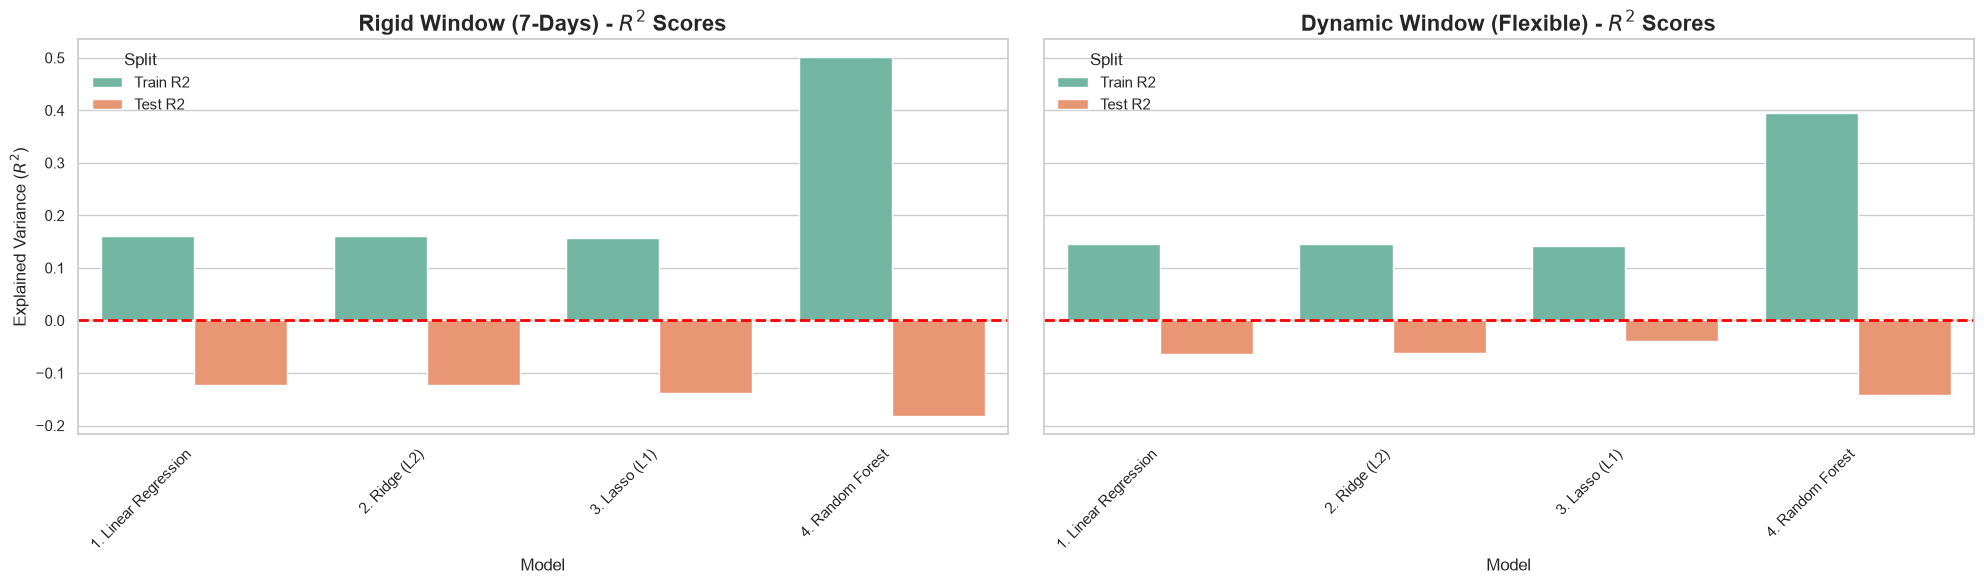

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("=== השוואת שונות מוסברת (R-Squared) - אימון מול מבחן ===")

# 1. סידור הנתונים (Melt) כדי שנוכל להציג Train ו-Test זה לצד זה
df_plot = final_results.melt(
    id_vars=['Dataset', 'Model'], 
    value_vars=['Train R2', 'Test R2'], 
    var_name='Split', 
    value_name='R2 Score'
)

# הגדרת סגנון הגרפים
sns.set_theme(style="whitegrid")

# שימוש ב-sharey=True כדי שציר ה-Y יהיה זהה בשני הגרפים ונזהה הבדלים בקלות
fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

# ---------------------------------------------------------
# גרף ימני (מקום 0 באנגלית): הגישה הקשיחה (Rigid)
# ---------------------------------------------------------
rigid_data = df_plot[df_plot['Dataset'] == 'Rigid (7-Days)']

sns.barplot(data=rigid_data, x='Model', y='R2 Score', hue='Split', ax=axes[0], palette='Set2')
axes[0].set_title('Rigid Window (7-Days) - $R^2$ Scores', fontsize=16, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylabel('Explained Variance ($R^2$)', fontsize=12)
axes[0].axhline(0, color='red', linestyle='--', linewidth=2) # קו אפס אדום בולט

# ---------------------------------------------------------
# גרף שמאלי (מקום 1 באנגלית): הגישה הדינמית (Dynamic)
# ---------------------------------------------------------
dynamic_data = df_plot[df_plot['Dataset'] == 'Dynamic (Flexible)']

sns.barplot(data=dynamic_data, x='Model', y='R2 Score', hue='Split', ax=axes[1], palette='Set2')
axes[1].set_title('Dynamic Window (Flexible) - $R^2$ Scores', fontsize=16, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylabel('') # הסרנו את התווית כי היא משותפת עם הגרף הראשון
axes[1].axhline(0, color='red', linestyle='--', linewidth=2) # קו אפס אדום בולט

plt.tight_layout()
plt.show()

רואים פשוט אוברפיטינג.. 

כותרת: מתי מדד R2 הופך לשלילי ולמה זה קורה בנתוני מבחן

מתי R2 הופך לשלילי?
השבר של SSres חלקי SStot משווה בין השגיאה של המודל שלך לבין השגיאה של מודל הבסיס:
אם המודל מושלם (SSres שווה 0): R2 שווה 1.
אם המודל מנבא בדיוק כמו ממוצע הנתונים (SSres שווה ל-SStot): R2 שווה 0.
אם המודל גרוע יותר מניחוש הממוצע (SSres גדול מ-SStot): השבר גדול מ-1, ולכן 1 פחות מספר גדול מ-1 ייתן תוצאה שלילית.

למה זה קורה במיוחד בנתוני מבחן (Test Set)?
ברגרסיה ליניארית רגילה על נתוני האימון (Train Set), המודל מותאם מתמטית למזער את SSres, ולכן R2 באימון תמיד יהיה בין 0 ל-1.
אבל כשמעבירים את המודל לנתוני מבחן חדשים (Test Set):
התאמת יתר (Overfitting): המודל שינן את הרעש של נתוני האימון, ובנתונים החדשים הניבויים שלו קופצים רחוק מאוד מהערכים האמיתיים.
זליגת נתונים או שינוי התפלגות: הניבויים כל כך מוטים, עד שלנחש לכל התצפיות במבחן פשוט את ממוצע הנתונים היה מניב שגיאה קטנה יותר מאשר להשתמש בניבויי המודל.

=== צפייה בביצועי כל 8 המודלים ===


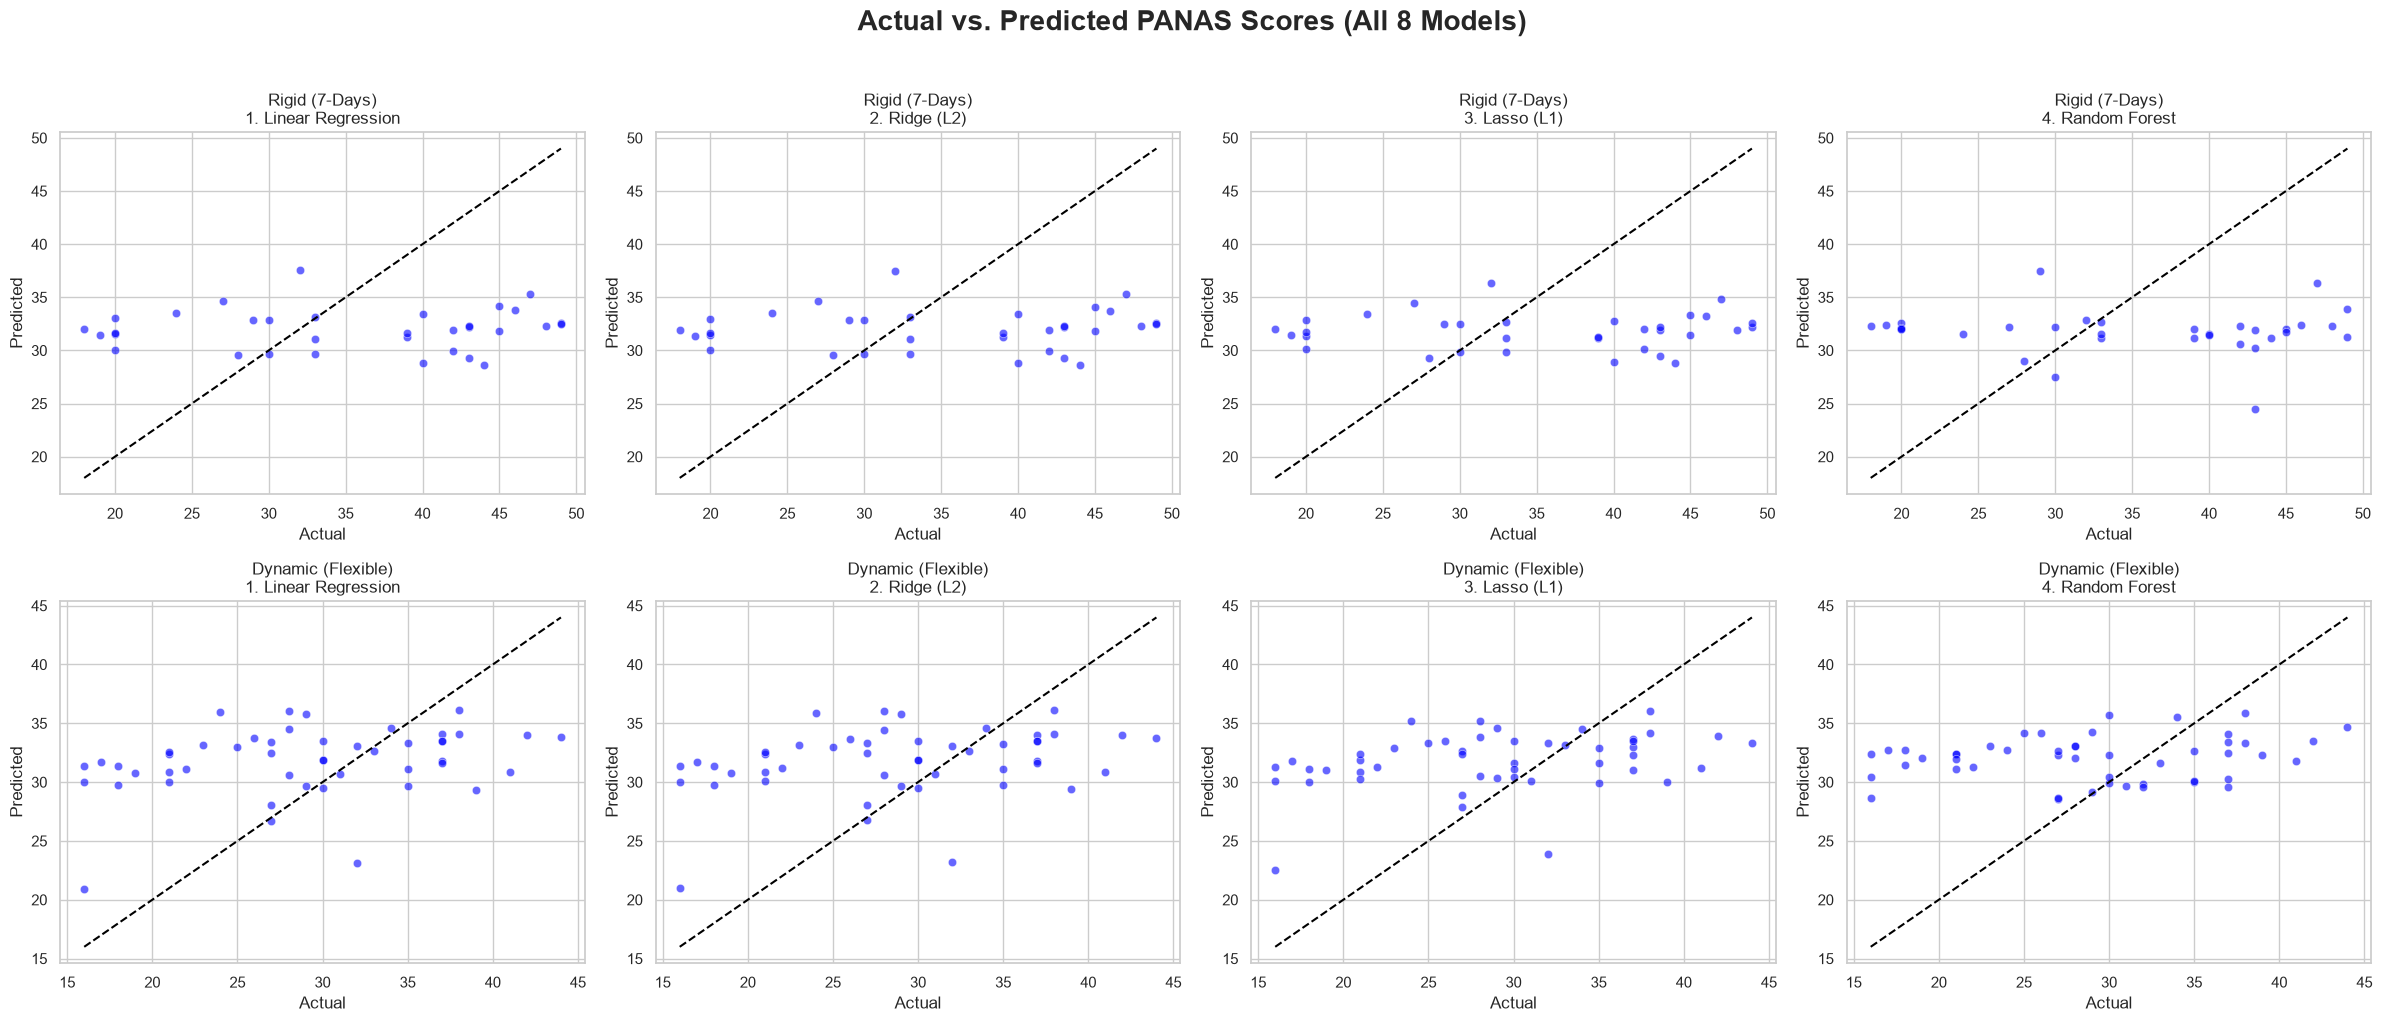

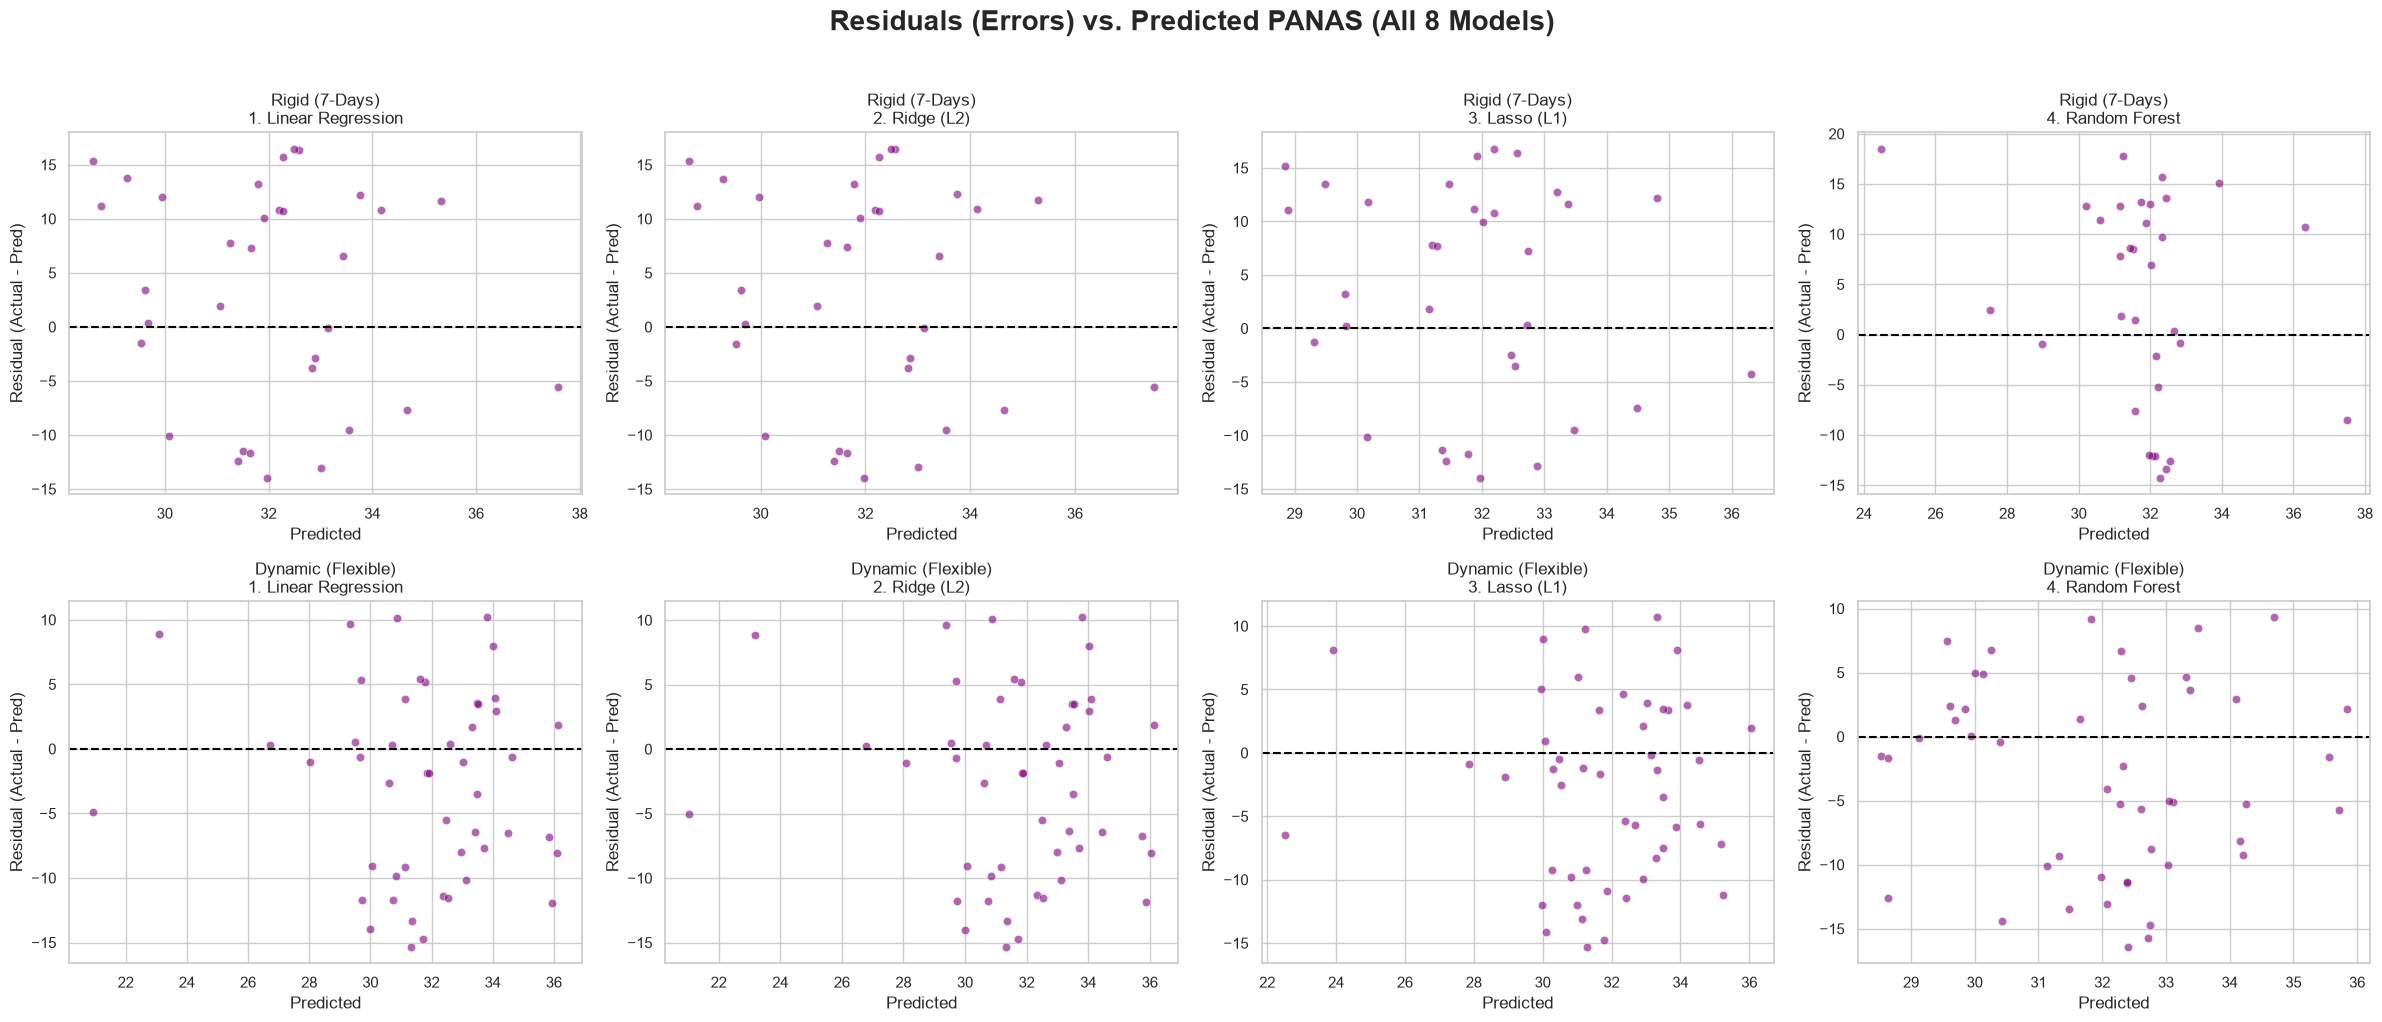

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=== צפייה בביצועי כל 8 המודלים ===")

# רשימת הגישות שלנו והנתונים שלהן
datasets = {
    'Rigid (7-Days)': (X_train_R, X_test_R, y_train_R, y_test_R),
    'Dynamic (Flexible)': (X_train_D, X_test_D, y_train_D, y_test_D)
}

# ---------------------------------------------------------
# 1. רשת גרפים: ניבוי מול מציאות (Actual vs Predicted)
# ---------------------------------------------------------
fig1, axes1 = plt.subplots(2, 4, figsize=(24, 10))
fig1.suptitle('Actual vs. Predicted PANAS Scores (All 8 Models)', fontsize=20, fontweight='bold', y=1.02)

for row_idx, (ds_name, (X_tr, X_te, y_tr, y_te)) in enumerate(datasets.items()):
    for col_idx, (model_name, model) in enumerate(models.items()):
        ax = axes1[row_idx, col_idx]
        
        # אימון וניבוי ספציפי
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        
        # ציור פיזור
        sns.scatterplot(x=y_te, y=y_pred, ax=ax, color='blue', alpha=0.6)
        
        # קו המטרה (Perfect Prediction)
        min_val = min(y_te.min(), y_pred.min())
        max_val = max(y_te.max(), y_pred.max())
        ax.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--')
        
        ax.set_title(f"{ds_name}\n{model_name}", fontsize=12)
        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. רשת גרפים: שגיאות / שאריות (Residuals vs Predicted)
# ---------------------------------------------------------
fig2, axes2 = plt.subplots(2, 4, figsize=(24, 10))
fig2.suptitle('Residuals (Errors) vs. Predicted PANAS (All 8 Models)', fontsize=20, fontweight='bold', y=1.02)

for row_idx, (ds_name, (X_tr, X_te, y_tr, y_te)) in enumerate(datasets.items()):
    for col_idx, (model_name, model) in enumerate(models.items()):
        ax = axes2[row_idx, col_idx]
        
        # אימון וניבוי (שוב, לוודא נתונים טריים)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        residuals = y_te - y_pred
        
        # ציור פיזור שאריות
        sns.scatterplot(x=y_pred, y=residuals, ax=ax, color='purple', alpha=0.6)
        ax.axhline(0, color='black', linestyle='--') # קו אפס שגיאה
        
        ax.set_title(f"{ds_name}\n{model_name}", fontsize=12)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Residual (Actual - Pred)')

plt.tight_layout()
plt.show()

**  הסברים לגרפים**
FIF 1: Actual vs. Predicted PANAS Scores
גרף זה משווה בין ציוני האמת בפועל (ציר X) לניבויי המודלים השונים (ציר Y), כאשר הקו המקווקו (y=x) מייצג ניבוי מושלם. ברוב המודלים (כולל ברגרסיה הליניארית הפשוטה ועיקרי המודלים הקונסים) ניכרת תופעת פשטנות-יתר (Underfitting) חריפה: בעוד ערכי האמת נפרסים על פני טווח נרחב (15–50), הניבויים מרוכזים בטווח צר סביב ממוצע הנתונים בלבד (~29). מכיוון שהתופעה חוזרת גם ללא קנסות רגולריזציה, כנראה שהמקור אינו במנגנון הענישה של המודל אלא בהיעדר קשר ליניארי חזק בין ממוצעי הרגשות השבועיים (EMA) לציוני ה-PANAS, דבר שמוביל את המודלים "להסתפק" בניבוי השואף לממוצע בלבד.

FIG 2: Residuals vs. Predicted PANAS Scores
גרף השאריות מציג את שגיאת המודל (ערך אמת פחות ניבוי) כפונקציה של הערך שנחזה. מודל תקין אמור להציג פיזור אקראי ואחיד סביב קו ה-0; מנגד, הגרפים מראים פיזור לא אחיד של השגיאות (הטרוסקדסטיות ואי-סימטריה) לאורך טווח הניבויים. חוסר האחידות בשגיאות מעיד על כך שהמודלים מתקשים להעריך נכונה מצבי קיצון רגשיים, וכי השגיאות אינן רעש אקראי בלבד. המסקנה המרכזית היא שהאגרגציה השבועית מיסכה את המידע הזמני, ויש צורך בהנדסת מאפיינים ברזולוציה גבוהה יותר (כגון חלונות זמן ממוקדים של 48 שעות) כדי לתפוס את התנודתיות הרגשית.

המעבר מאגרגציה נאיבית להנדסת מאפיינים מבוססת-זמן (Temporal Feature Engineering)
ניתוח ממצאי שלב ה-Baseline
ניתוח תוצאות המודלים הראשוניים בשלב Baseline העלה תובנה קריטית: מודלים שהתבססו על ממוצע פשוט של חלון זמן קבוע של 7 ימים נכשלו בניבוי והציגו R2 שלילי חריף על נתוני המבחן. לעומת זאת, שימוש בחלון זמן דינאמי המתמקד רק בדיווחים רלוונטיים עד לשאלון הקודם בלם את הקריסה במודלים הליניאריים. מודלים אלו הציגו יציבות יחסית והגיעו בנתוני המבחן ל-R2 שקרוב לאפס. כלומר, הם סיפקו ניבוי הקרוב לממוצע הכללי אך לא פגעו בביצועים מעבר לכך. במקביל, במודל היער האקראי Random Forest ניכרה התאמת יתר Overfitting חריפה בשתי הגישות עקב המדגם המצומצם.

הרקע התיאורטי והפסיכולוגי
העובדה שצמצום או התאמת חלון הזמן מנעה הידרדרות לערכים שליליים במודלים הליניאריים, מעידה על כך שחלון זמן דינאמי או קצר יותר מחזיק בערך מוסף. ממצא אמפירי זה מסתדר היטב עם הספרות הפסיכולוגית הקוגניטיבית העוסקת בדיווח רטרוספקטיבי. חישוב ממוצע נאיבי מניח כי לדיווח רגשי מלפני שבוע יש משקל זהה לדיווח מהבוקר. אולם, מילוי שאלוני PANAS מושפע מהטיות זיכרון ידועות: אפקט האחרונות Recency Effect, הגורם לנבדקים לתת משקל יתר לרגשות שחוו ב-48 השעות האחרונות, וחוק השיא והסוף Peak-End Rule של כהנמן, לפיו חוויות מוערכות על בסיס רגעי הקיצון שלהן.

המסקנה המחקרית וצעדי ההמשך
לאור זאת, המסקנה המחקרית היא כי האגרגציה השבועית השטוחה מיסכה את הסיגנל האמיתי בנתונים ויצרה רעש. כדי לשפר את כושר הניבוי, יש צורך בהנדסת מאפיינים Feature Engineering שאינה מתייחסת לזמן כמרחב שטוח, אלא מחלצת מאפיינים מבוססי-הטיה: פיצול חלונות זמן כמו הפרדת 48 השעות האחרונות משאר השבוע, שימוש בפונקציות דעיכה Time-Decay, וזיהוי אירועי קיצון Peaks חיוביים ושליליים.

# שלב 6: הנדסת מאפיינים מבוססת-זמן (Ablation Study: 48h Window vs. Exponential Time-Decay)

בשני התאים הבאים אנו מציגים הנדסת מאפיינים מתקדמת (Feature Engineering) שנועדה לבחון את השערת אפקט האחרונות (Recency Effect) ולהתגבר על בעיית השטת הנתונים שזיהינו במודלי הבסיס. 
במקום לעשות ממוצע שבועי אריתמטי שטוח, אנו מייצרים שתי טבלאות נתונים נפרדות מתוך החלון הדינמי:
1. **טבלת חלונות מפוצלים (`split_window_wide_df`):** מפצלת את הדיווחים בתוך החלון הדינמי לפרופורציית רגשות ב-48 השעות שלפני השאלון לעומת שאר השבוע (ימים 3–7).
2. **טבלת דעיכה בזמן (`decay_wide_df`):** מעניקה לכל דיווח משקל רציף הדועך מעריכית ככל שהדיווח רחוק מתאריך מילוי ה-PANAS ($w = e^{-\lambda \cdot d}$).

בשתי הטבלאות מחושב מדד תנודתיות רגשית (אנטרופיה), ומבוצעת הסרה כפולה/בודדת של קטגוריית הייחוס (`NEUTRAL`) למניעת מולטי-קוליניאריות. לבסוף, מבוצע פיצול מרובד ברמת המשתמש (Stratified Group Split) למניעת זליגת נתונים (Data Leakage) בין האימון למבחן.

In [28]:
import pandas as pd
import numpy as np
from scipy.stats import entropy
from sklearn.model_selection import train_test_split

print("=== שלב 6: הנדסת מאפיינים מתקדמת בחלון דינמי (Dynamic Temporal Feature Engineering) ===")

# הגדרת כלל הרגשות המדויקים כפי שהם מופיעים בטקסט
all_moods = ['ALERT', 'HAPPY', 'NEUTRAL', 'RESTED/RELAXED', 'SAD', 'TENSE/ANXIOUS', 'TIRED']

# העמודה האמיתית שבה שמור הרגש בנתונים שלך
MOOD_COL = 'data.MOOD'

split48_records = []
decay_records = []

# 1. וידוא מיון תאריכים תקין למניעת זליגת נתונים
panas_sorted = panas_base.sort_values(by=['user_id', 'panas_date']).reset_index(drop=True)
ema_sorted = ema_base.sort_values(by=['user_id', 'ema_date']).reset_index(drop=True)

total_panas_count = len(panas_sorted)
dropped_no_ema_count = 0

# =====================================================================
# 2. לולאת חילוץ נתונים מבוססת חלון דינמי
# =====================================================================
for idx, panas_row in panas_sorted.iterrows():
    user = panas_row['user_id']
    p_date = panas_row['panas_date']
    
    # חישוב חלון דינמי
    prev_panas = panas_sorted[(panas_sorted['user_id'] == user) & (panas_sorted['panas_date'] < p_date)]
    if not prev_panas.empty:
        prev_date = prev_panas['panas_date'].max()
        start_date = max(p_date - pd.Timedelta(days=7), prev_date)
    else:
        start_date = p_date - pd.Timedelta(days=7)
        
    # סינון דיווחי ה-EMA של המשתמש בתוך החלון הדינמי בלבד
    mask = (ema_sorted['user_id'] == user) & (ema_sorted['ema_date'] > start_date) & (ema_sorted['ema_date'] <= p_date)
    user_ema = ema_sorted[mask].copy()
    
    # תנאי מחיקה: אם אין דיווחי EMA בחלון
    if len(user_ema) == 0:
        dropped_no_ema_count += 1
        continue

    # חישוב מטא-דאטה של מסגרת הזמן
    actual_window_hours = max((p_date - start_date).total_seconds() / 3600.0, 1.0)
    actual_window_days = actual_window_hours / 24.0
    ema_count = len(user_ema)
    ema_density = ema_count / actual_window_days
    
    base_record = {
        'user_id': user,
        'panas_original_id': panas_row['panas_original_id'],
        'panas_date': p_date,
        'positive_affect_score': panas_row['positive_affect_score'],
        'negative_affect_score': panas_row['negative_affect_score'],
        'total_emas_in_window': ema_count,
        'window_days': round(actual_window_days, 2),
        'ema_density_per_day': round(ema_density, 2)
    }

    # ---------------------------------------------------------
    # אסטרטגיה 1: חלונות מפוצלים בחלון דינמי (SPLIT 48H)
    # ---------------------------------------------------------
    split_rec = base_record.copy()
    threshold_date = p_date - pd.Timedelta(hours=48)
    
    ema_48h = user_ema[user_ema['ema_date'] > threshold_date]
    ema_rest = user_ema[user_ema['ema_date'] <= threshold_date]
    
    # חישוב הפרופורציה (כמה פעמים הרגש מופיע כטקסט בעמודה data.MOOD)
    for m in all_moods:
        split_rec[f'mood_{m}_48h'] = (ema_48h[MOOD_COL] == m).mean() if len(ema_48h) > 0 else 0.0
        split_rec[f'mood_{m}_rest'] = (ema_rest[MOOD_COL] == m).mean() if len(ema_rest) > 0 else 0.0

    # מציאת הרגש הדומיננטי בשאר הימים
    if len(ema_rest) > 0:
        mode_val = ema_rest[MOOD_COL].mode()
        dominant_rest = mode_val.iloc[0] if not mode_val.empty else 'NEUTRAL'
    else:
        dominant_rest = 'NONE'
        
    split_rec['dominant_mood_rest'] = dominant_rest
    split48_records.append(split_rec)
    
    # ---------------------------------------------------------
    # אסטרטגיה 2: דעיכה מעריכית בחלון דינמי (DECAY)
    # ---------------------------------------------------------
    decay_rec = base_record.copy()
    user_ema['delta_days'] = (p_date - user_ema['ema_date']).dt.total_seconds() / 86400.0
    user_ema['weight'] = np.exp(-0.3 * user_ema['delta_days'])
    total_weight = user_ema['weight'].sum()
    
    for m in all_moods:
        # סכימת המשקולות רק עבור השורות שבהן הטקסט שווה לרגש הנוכחי
        m_weight = user_ema.loc[user_ema[MOOD_COL] == m, 'weight'].sum()
        decay_rec[f'mood_{m}_decay'] = m_weight / total_weight if total_weight > 0 else 0.0
        
    decay_records.append(decay_rec)

# יצירת DataFrames
split48_wide_df = pd.DataFrame(split48_records)
decay_wide_df = pd.DataFrame(decay_records)

# =====================================================================
# 3. הנדסת מאפיינים: אנטרופיה והסרת קטגוריית ייחוס למניעת קוליניאריות
# =====================================================================
# SPLIT48
cols_48h = [c for c in split48_wide_df.columns if c.startswith('mood_') and '48h' in c]
cols_rest = [c for c in split48_wide_df.columns if c.startswith('mood_') and 'rest' in c]

split48_wide_df['entropy_48h'] = split48_wide_df[cols_48h].apply(lambda r: entropy(r + 1e-9), axis=1)
split48_wide_df['entropy_rest'] = split48_wide_df[cols_rest].apply(lambda r: entropy(r + 1e-9), axis=1)

split48_wide_df.drop(columns=['mood_NEUTRAL_48h', 'mood_NEUTRAL_rest'], inplace=True, errors='ignore')
split48_wide_df = pd.get_dummies(split48_wide_df, columns=['dominant_mood_rest'], drop_first=True)

# DECAY
cols_decay = [c for c in decay_wide_df.columns if c.startswith('mood_') and 'decay' in c]
decay_wide_df['mood_volatility_entropy'] = decay_wide_df[cols_decay].apply(lambda r: entropy(r + 1e-9), axis=1)
decay_wide_df.drop(columns=['mood_NEUTRAL_decay'], inplace=True, errors='ignore')

# =====================================================================
# 4. הדפסה ופיצול
# =====================================================================
print("\n" + "="*60)
print("📊 סיכום ספירת תצפיות ותנאי סינון")
print("="*60)
print(f"🔹 סה\"כ שאלונים במאגר המקורי (PANAS): {total_panas_count}")
print(f"❌ שאלונים שהושמטו עקב 0 דיווחי EMA בחלון הדינמי: {dropped_no_ema_count}")
print(f"✅ סה\"כ תצפיות סופיות בטבלת SPLIT 48H: {len(split48_wide_df)}")
print(f"✅ סה\"כ תצפיות סופיות בטבלת DECAY: {len(decay_wide_df)}")

split48_train_df, split48_test_df, split48_user_stats = stratified_group_split(
    split48_wide_df, user_col='user_id', test_size=0.2, random_state=42
)

decay_train_df, decay_test_df, decay_user_stats = stratified_group_split(
    decay_wide_df, user_col='user_id', test_size=0.2, random_state=42
)

print("\n--- SPLIT 48H Train Dataset Preview ---")
display(split48_train_df.head(3))

=== שלב 6: הנדסת מאפיינים מתקדמת בחלון דינמי (Dynamic Temporal Feature Engineering) ===

📊 סיכום ספירת תצפיות ותנאי סינון
🔹 סה"כ שאלונים במאגר המקורי (PANAS): 268
❌ שאלונים שהושמטו עקב 0 דיווחי EMA בחלון הדינמי: 54
✅ סה"כ תצפיות סופיות בטבלת SPLIT 48H: 214
✅ סה"כ תצפיות סופיות בטבלת DECAY: 214

--- SPLIT 48H Train Dataset Preview ---


,user_id,panas_original_id,panas_date,positive_affect_score,negative_affect_score,total_emas_in_window,window_days,ema_density_per_day,mood_ALERT_48h,mood_ALERT_rest,...,mood_TIRED_rest,entropy_48h,entropy_rest,dominant_mood_rest_HAPPY,dominant_mood_rest_NEUTRAL,dominant_mood_rest_NONE,dominant_mood_rest_RESTED/RELAXED,dominant_mood_rest_SAD,dominant_mood_rest_TENSE/ANXIOUS,dominant_mood_rest_TIRED
0,621e2eaf67b776a2406b14ac,panas_9,2022-01-05,33,21,2,7.0,0.29,0.500000,0.0,...,0.0,0.693147,1.945910,False,False,True,False,False,False,False
1,621e2eaf67b776a2406b14ac,panas_10,2022-01-07,26,16,6,2.0,3.00,0.166667,0.0,...,0.0,1.560710,1.945910,False,False,True,False,False,False,False
2,621e2eaf67b776a2406b14ac,panas_8,2022-01-10,27,12,7,3.0,2.33,0.000000,0.0,...,0.5,1.332179,0.693147,False,False,False,True,False,False,False


=== שלב 7: אימון והערכת מודלים על מאפייני זמן מתקדמים (Ablation Study) ===

תוצאות ניבוי עבור משתנה המטרה: positive_affect_score


,Dataset,Model,Train RMSE,Test RMSE,Train R2,Test R2
0,Split Window (48h/Rest),1. Linear Regression,6.36,8.31,0.271,-0.228
1,Split Window (48h/Rest),2. Ridge (L2),6.36,8.26,0.270,-0.215
2,Split Window (48h/Rest),3. Lasso (L1),6.45,7.97,0.250,-0.131
3,Split Window (48h/Rest),4. Random Forest,5.22,7.36,0.508,0.036
4,Time-Decay (Exponential),1. Linear Regression,6.85,7.88,0.154,-0.105
5,Time-Decay (Exponential),2. Ridge (L2),6.85,7.88,0.154,-0.104
6,Time-Decay (Exponential),3. Lasso (L1),6.86,7.81,0.153,-0.084
7,Time-Decay (Exponential),4. Random Forest,5.57,7.96,0.440,-0.127



=== השוואת שונות מוסברת (R-Squared) - אימון מול מבחן ===


C:\Users\naama\AppData\Local\Temp\ipykernel_34412\1414945936.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
C:\Users\naama\AppData\Local\Temp\ipykernel_34412\1414945936.py:114: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


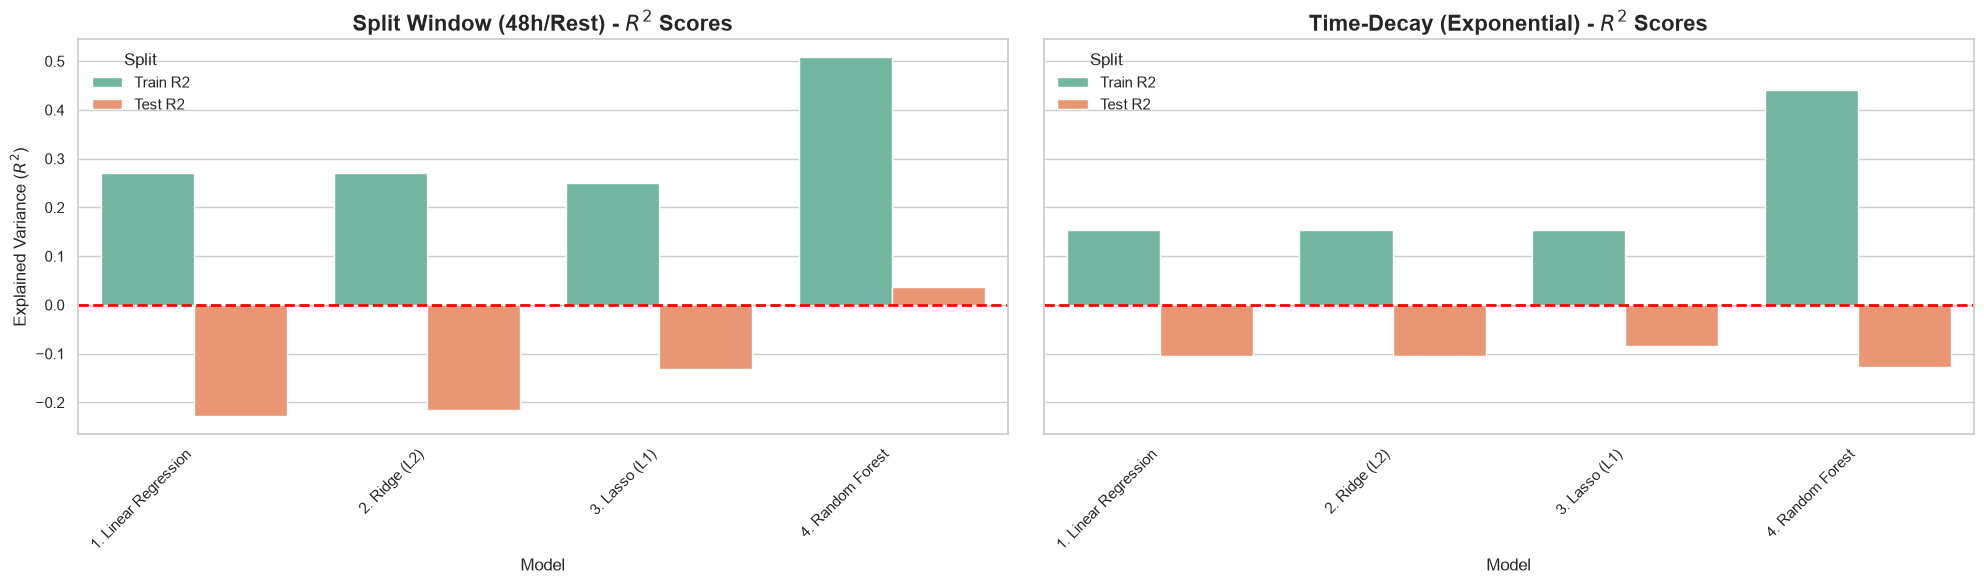


=== צפייה בביצועי כל 8 המודלים (ניתוח שגיאות) ===


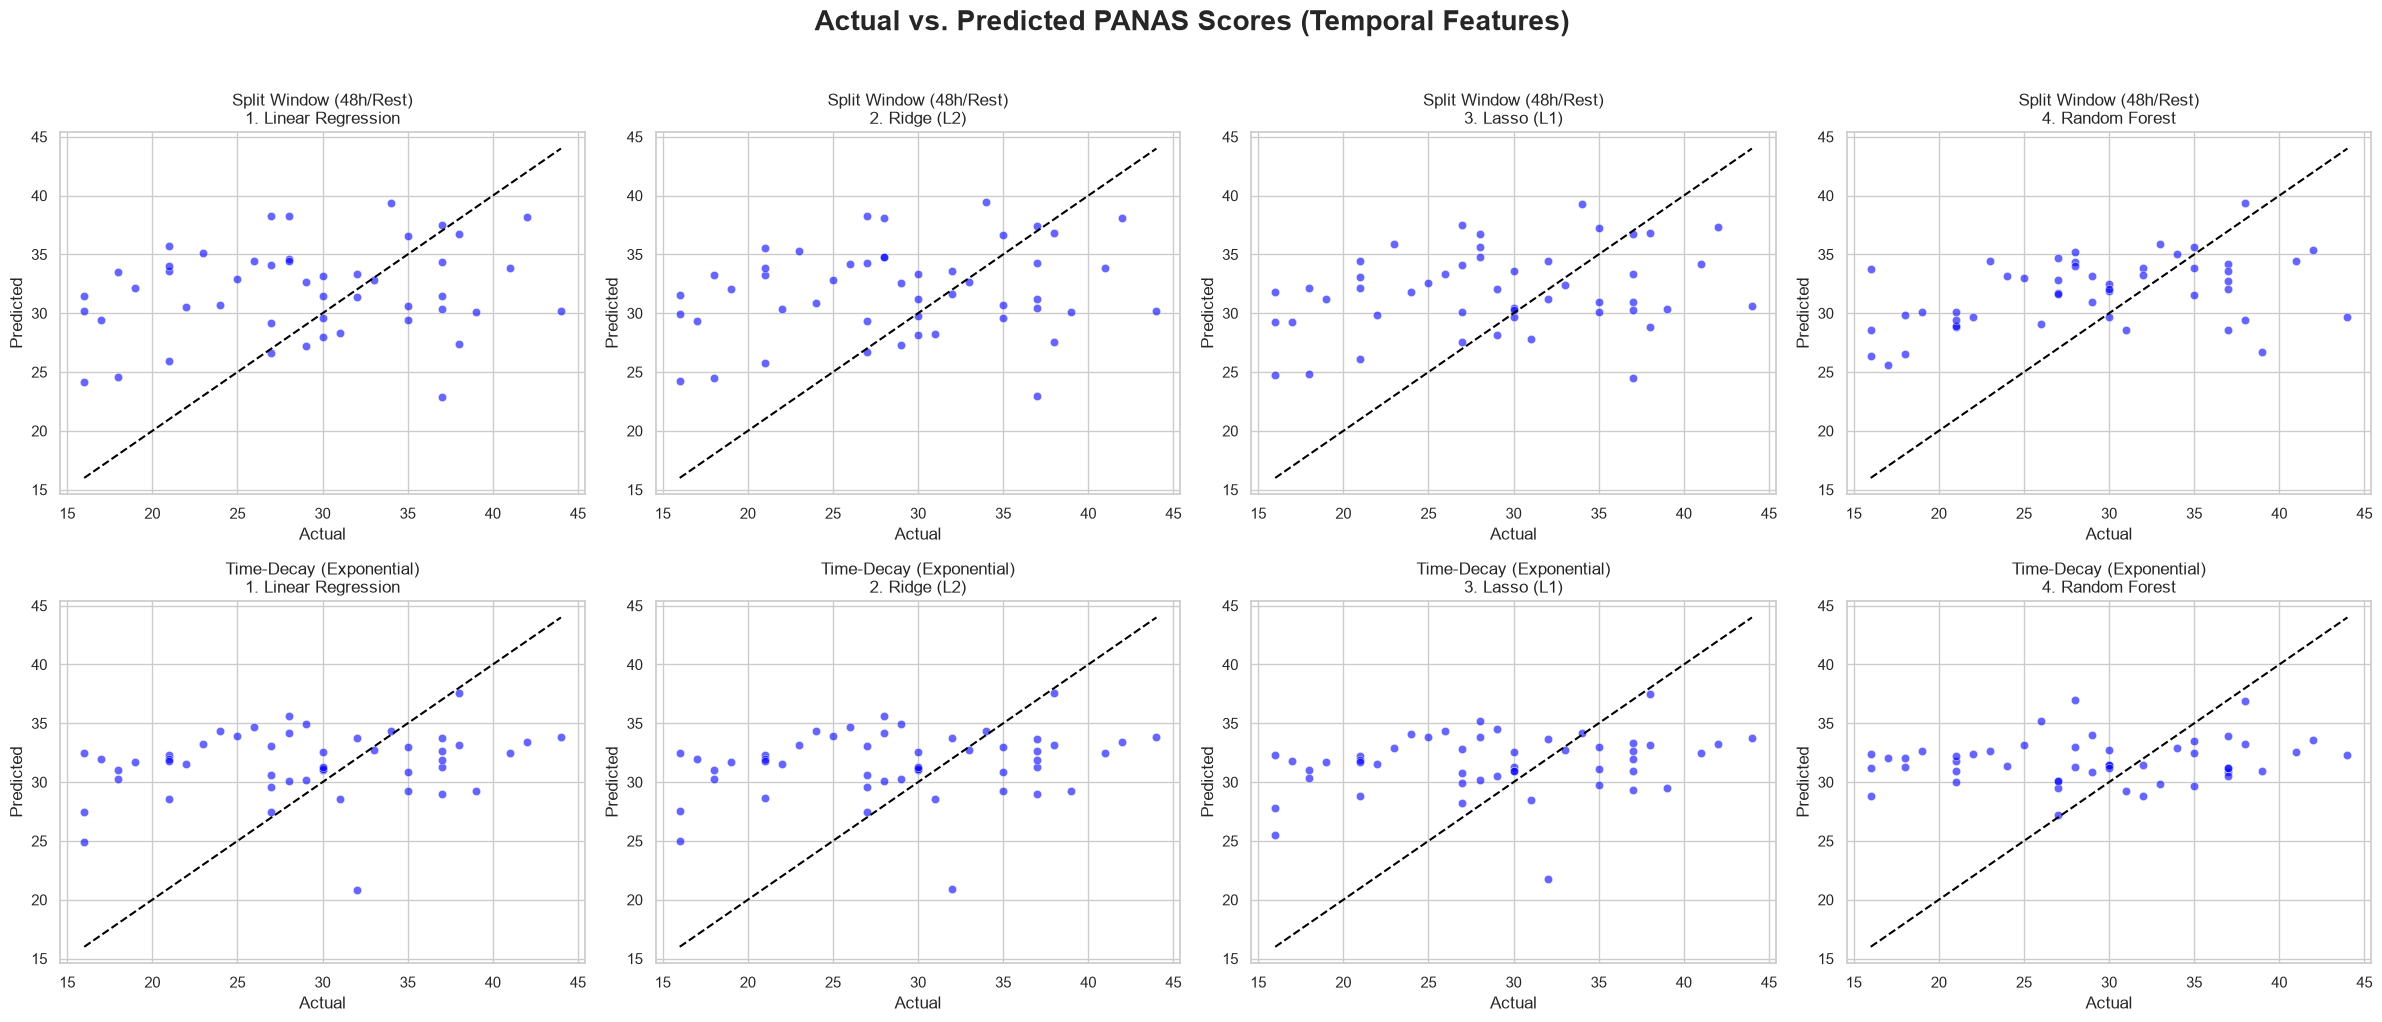

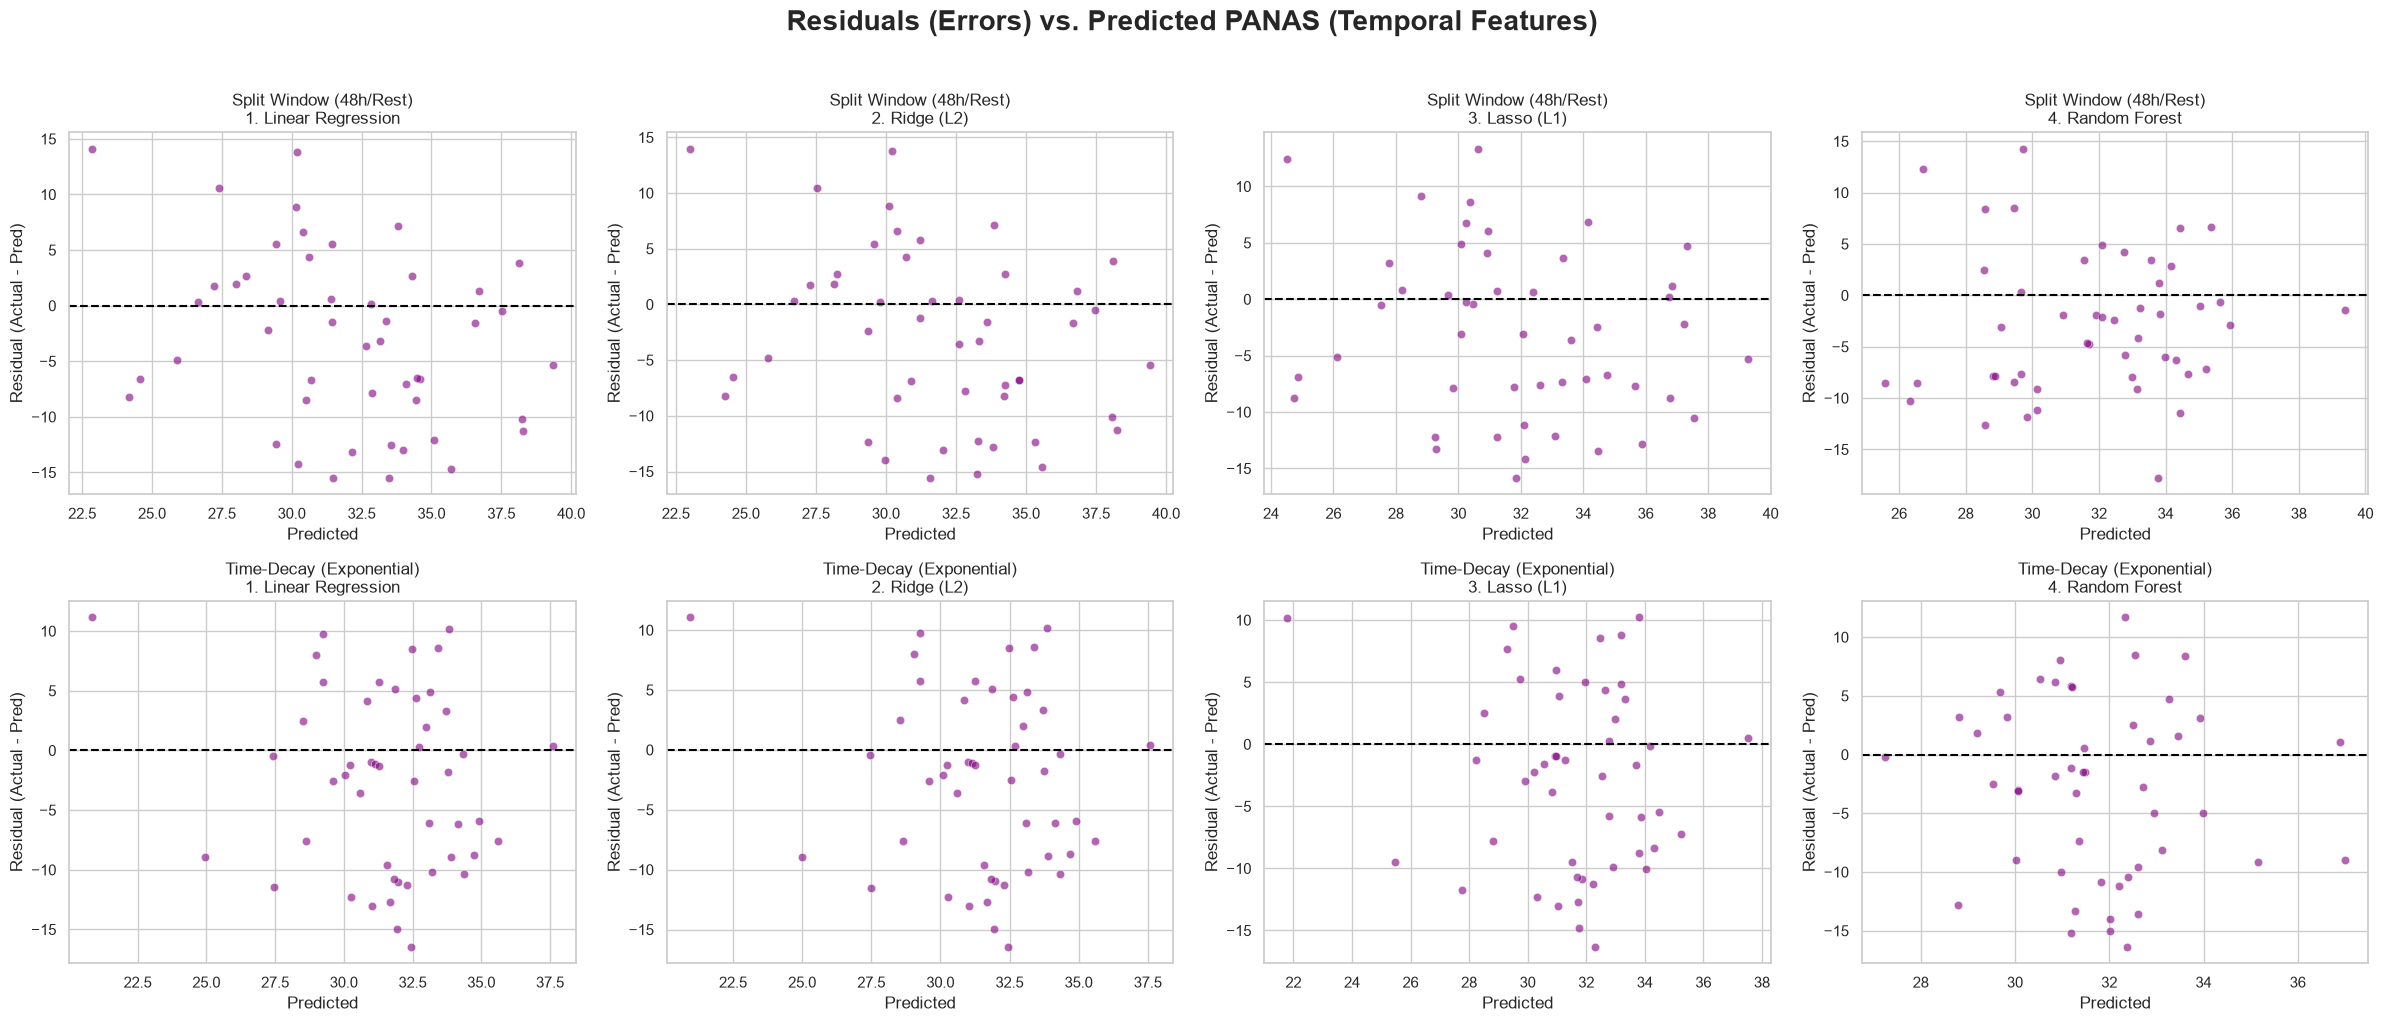

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("=== שלב 7: אימון והערכת מודלים על מאפייני זמן מתקדמים (Ablation Study) ===")

# הגדרת משתנה המטרה והעמודות שיש להשמיט
TARGET = 'positive_affect_score'
# הוספנו להשמטה גם את משתני המטא-דאטה החדשים כדי שהמודל ילמד רק מהרגשות
DROP_COLS = ['user_id', 'panas_original_id', 'panas_date', 'positive_affect_score', 'negative_affect_score', 
             'total_emas_in_window', 'window_days', 'ema_density_per_day']

# פונקציה להכנת הנתונים (הפרדה וסילום)
def prepare_data(train_df, test_df, target_col, drop_cols):
    # וידוא שעמודות ההשמטה אכן קיימות בטבלה כדי למנוע שגיאות
    cols_to_drop = [c for c in drop_cols if c in train_df.columns]
    
    X_train = train_df.drop(columns=cols_to_drop)
    y_train = train_df[target_col]
    X_test = test_df.drop(columns=cols_to_drop)
    y_test = test_df[target_col]
    
    # סילום הנתונים (Standardization)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # החזרת הנתונים המנורמלים כ-DataFrame לשמירה על שמות העמודות
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
    
    return X_train_scaled, X_test_scaled, y_train, y_test

# הכנת הנתונים לשתי הגישות החדשות
X_train_S, X_test_S, y_train_S, y_test_S = prepare_data(split48_train_df, split48_test_df, TARGET, DROP_COLS)
X_train_D, X_test_D, y_train_D, y_test_D = prepare_data(decay_train_df, decay_test_df, TARGET, DROP_COLS)

# =====================================================================
# הגדרת המודלים
# =====================================================================
models = {
    '1. Linear Regression': LinearRegression(),
    '2. Ridge (L2)': Ridge(alpha=1.0),
    '3. Lasso (L1)': Lasso(alpha=0.1),
    '4. Random Forest': RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42)
}

# פונקציה לאימון והערכת מילון מודלים
def evaluate_models(X_train, X_test, y_train, y_test, dataset_name):
    results = []
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        
        rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
        rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
        r2_train = r2_score(y_train, y_pred_train)
        r2_test = r2_score(y_test, y_pred_test)
        
        results.append({
            'Dataset': dataset_name,
            'Model': name,
            'Train RMSE': round(rmse_train, 2),
            'Test RMSE': round(rmse_test, 2),
            'Train R2': round(r2_train, 3),
            'Test R2': round(r2_test, 3)
        })
        
    return pd.DataFrame(results)

# הרצה ואיחוד התוצאות
results_split = evaluate_models(X_train_S, X_test_S, y_train_S, y_test_S, 'Split Window (48h/Rest)')
results_decay = evaluate_models(X_train_D, X_test_D, y_train_D, y_test_D, 'Time-Decay (Exponential)')

final_results = pd.concat([results_split, results_decay], ignore_index=True)

print(f"\nתוצאות ניבוי עבור משתנה המטרה: {TARGET}\n" + "="*50)
display(final_results)

# =====================================================================
# 1. גרף השוואת R-Squared (אימון מול מבחן)
# =====================================================================
print("\n=== השוואת שונות מוסברת (R-Squared) - אימון מול מבחן ===")

df_plot = final_results.melt(
    id_vars=['Dataset', 'Model'], 
    value_vars=['Train R2', 'Test R2'], 
    var_name='Split', 
    value_name='R2 Score'
)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

# גרף ימני: גישת החלון המפוצל
split_data = df_plot[df_plot['Dataset'] == 'Split Window (48h/Rest)']
sns.barplot(data=split_data, x='Model', y='R2 Score', hue='Split', ax=axes[0], palette='Set2')
axes[0].set_title('Split Window (48h/Rest) - $R^2$ Scores', fontsize=16, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylabel('Explained Variance ($R^2$)', fontsize=12)
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)

# גרף שמאלי: גישת הדעיכה המעריכית
decay_data = df_plot[df_plot['Dataset'] == 'Time-Decay (Exponential)']
sns.barplot(data=decay_data, x='Model', y='R2 Score', hue='Split', ax=axes[1], palette='Set2')
axes[1].set_title('Time-Decay (Exponential) - $R^2$ Scores', fontsize=16, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylabel('') 
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)

plt.tight_layout()
plt.show()

# =====================================================================
# 2. רשתות גרפים לניתוח שגיאות (Actual vs Predicted & Residuals)
# =====================================================================
print("\n=== צפייה בביצועי כל 8 המודלים (ניתוח שגיאות) ===")

datasets = {
    'Split Window (48h/Rest)': (X_train_S, X_test_S, y_train_S, y_test_S),
    'Time-Decay (Exponential)': (X_train_D, X_test_D, y_train_D, y_test_D)
}

# רשת 1: ניבוי מול מציאות
fig1, axes1 = plt.subplots(2, 4, figsize=(24, 10))
fig1.suptitle('Actual vs. Predicted PANAS Scores (Temporal Features)', fontsize=20, fontweight='bold', y=1.02)

for row_idx, (ds_name, (X_tr, X_te, y_tr, y_te)) in enumerate(datasets.items()):
    for col_idx, (model_name, model) in enumerate(models.items()):
        ax = axes1[row_idx, col_idx]
        
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        
        sns.scatterplot(x=y_te, y=y_pred, ax=ax, color='blue', alpha=0.6)
        
        min_val = min(y_te.min(), y_pred.min())
        max_val = max(y_te.max(), y_pred.max())
        ax.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--')
        
        ax.set_title(f"{ds_name}\n{model_name}", fontsize=12)
        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')

plt.tight_layout()
plt.show()

# רשת 2: שאריות
fig2, axes2 = plt.subplots(2, 4, figsize=(24, 10))
fig2.suptitle('Residuals (Errors) vs. Predicted PANAS (Temporal Features)', fontsize=20, fontweight='bold', y=1.02)

for row_idx, (ds_name, (X_tr, X_te, y_tr, y_te)) in enumerate(datasets.items()):
    for col_idx, (model_name, model) in enumerate(models.items()):
        ax = axes2[row_idx, col_idx]
        
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        residuals = y_te - y_pred
        
        sns.scatterplot(x=y_pred, y=residuals, ax=ax, color='purple', alpha=0.6)
        ax.axhline(0, color='black', linestyle='--')
        
        ax.set_title(f"{ds_name}\n{model_name}", fontsize=12)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Residual (Actual - Pred)')

plt.tight_layout()
plt.show()

ממצאי שלב האימון
בשלב זה, בעקבות תיקון תשתית הנתונים והנגשת עמודות הרגש המפורשות, ניכר כי המודלים הצליחו לזהות סיגנל בנתוני האימון (Train Set). המודלים הליניאריים הצליחו להסביר כ-16% מהשונות בנתוני האימון, בעוד שמודל היער האקראי Random Forest הגיע לכושר הסבר מרשים של כ-53% מהשונות (R2 של 0.528). ממצאים אלו מראים כי קיימת חוקיות פנימית בין דיווחי ה-EMA המוקדמים לבין ציוני PANAS בקרב המשתתפים שעל נתוניהם המודל התאמן.

אתגר ההכללה בנתוני המבחן
על אף ההצלחה בשלב האימון, בנתוני המבחן (Test Set) כל המודלים קורסים לערכי R2 שליליים. ניתוח מעמיק של התופעה מעיד כי הסיבה אינה נובעת מחיסרון בכמות השורות או במדגם, אלא מאתגר מתודי מובנה של שונות בין אישית עצומה (Inter-personal Variability). מכיוון שחלוקת הנתונים בוצעה ברמת המשתמש (User-level split) כדי למנוע זליגת מידע, המודל נדרש ללמוד קבוצת נבדקים אחת ולנבא ציונים עבור נבדקים חדשים לחלוטין שהוא מעולם לא נחשף אליהם.

המסקנה המחקרית
הפער החד בין ביצועי האימון לביצועי המבחן מצביע על התאמת יתר (Overfitting) לדפוסי הדיווח הספציפיים של נבדקי האימון. במחקר פסיכולוגי, התרגום הסובייקטיבי של דיווח רגשי רגעי (כמו הדיווח TIRED ב-EMA) לציון מספרי בשאלון PANAS משתנה בין אדם לאדם. כתוצאה מכך, מודלים הלומדים אך ורק תדירויות ופרופורציות של דיווחי רגשות סובייקטיביים מתקשים לייצר חוקיות אוניברסלית המכלילה על משתמשים חדשים. ממצא זה מהווה צידוק מחקרי מרכזי לשילוב נתונים פיזיולוגיים אובייקטיביים בשלבים הבאים, במטרה לספק עוגן פיזיולוגי שיגשר על השונות הבין-אישית.

רעיון נוסף לנסות לראות אם יש סף של נמוכים וגבוהים והאם המודל שעד עכשיו ניסה לנבא באופן רציף ינבא טוב יותר גבוהים ונמוכים. שכן בסוף אנחנו מעוניינים לתפוס את הגבוהים. 

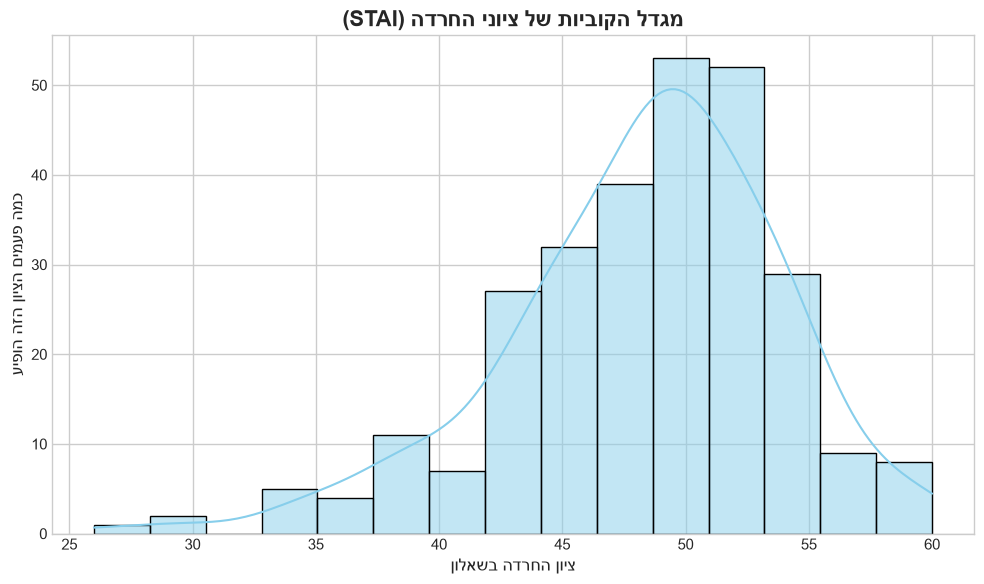

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. מגדירים מאיפה לקחת את הנתונים (מתוך תיקיית הפרויקט שלכן)
current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == "notebooks" else current_dir
DATA_DIR = PROJECT_ROOT / "data" / "processed_parquet"

# 2. פותחים את הקופסה של ציוני החרדה בלבד
stai_df = pd.read_parquet(DATA_DIR / "stai.parquet")

# 3. מכינים דף ציור נקי ויפה
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6))

# 4. מציירים את מגדל הקוביות מתוך הנתונים שפתחנו
sns.histplot(stai_df['stai_stress'], bins=15, kde=True, color='skyblue', edgecolor='black')

# 5. נותנים כותרות ברורות שהגדרנו קודם
plt.title("מגדל הקוביות של ציוני החרדה (STAI)", fontsize=16, fontweight='bold')
plt.xlabel("ציון החרדה בשאלון", fontsize=12)
plt.ylabel("כמה פעמים הציון הזה הופיע", fontsize=12)

plt.tight_layout()
plt.show()

רציתי לבדוק שיש פיזור בכלל ויש אנשים שיעברו את סף ה-40 אבל פה רואים את כל השאלונים. עכשיו צריך להבין האם זה אדם אחד שעונה הרבה פעמים ומטה את הקבוצה או הרבה אנשים

In [31]:
import pandas as pd

# הגדרת הסף שלנו
threshold = 40

# יצירת העמודה הבינארית לסימון רמת החרדה
stai_df['anxiety_level'] = stai_df['stai_stress'].apply(
    lambda x: 'High Anxiety (>=40)' if x >= threshold else 'Low Anxiety (<40)'
)

# קיבוץ הנתונים וספירה חכמה - הפעם עם השם המדויק user_id
summary_df = stai_df.groupby('anxiety_level').agg(
    total_questionnaires=('stai_stress', 'count'),
    unique_users=('user_id', 'nunique')             
).reset_index()

# הצגת התוצאה בטבלה
display(summary_df)

,anxiety_level,total_questionnaires,unique_users
0,High Anxiety (>=40),256,52
1,Low Anxiety (<40),23,7


טוב זה ממש לא טוב מלא מהנבדקים מעל 40 וממש קצת מתחת אז אני מנסה להבין אולי מה יהיה סף הגיוני אחר. 

In [32]:
import pandas as pd

# 1. מציאת החציון (הנקודה שחוצה את המדגם לחצי)
median_score = stai_df['stai_stress'].median()
print(f"החציון של המדגם שלנו הוא: {median_score}\n")

# 2. יצירת עמודת מטרה חדשה לפי החציון
stai_df['anxiety_level_median'] = stai_df['stai_stress'].apply(
    lambda x: 'High Anxiety (>= Median)' if x >= median_score else 'Low Anxiety (< Median)'
)

# 3. בדיקת כמות המשתמשים השונים בכל קבוצה עכשיו
summary_median_df = stai_df.groupby('anxiety_level_median').agg(
    total_questionnaires=('stai_stress', 'count'),
    unique_users=('user_id', 'nunique')             
).reset_index()

# 4. הצגת התוצאה המאוזנת
display(summary_median_df)

החציון של המדגם שלנו הוא: 49.0



,anxiety_level_median,total_questionnaires,unique_users
0,High Anxiety (>= Median),151,44
1,Low Anxiety (< Median),128,39


יצר בעצם סף חדש שהוא 49

בסוף החלטנו להשתמש בטבלאות של מוריה ולכן לעשות את מה שרצינו בSTAI על PANAS 

תוצאות: עוד לא ניתחתי 

In [33]:
import pandas as pd

# 1. ממירים את התאריכים לאותו פורמט (והפעם משתמשים ב-submitdate עבור ה-STAI)
stai_df['submitdate'] = pd.to_datetime(stai_df['submitdate']).dt.normalize()
dynamic_wide_df['panas_date'] = pd.to_datetime(dynamic_wide_df['panas_date']).dt.normalize()
decay_wide_df['panas_date'] = pd.to_datetime(decay_wide_df['panas_date']).dt.normalize()

# 2. ממזגים את הציון של STAI לתוך הטבלה הרגילה
dynamic_with_stai = pd.merge(
    dynamic_wide_df,
    stai_df[['user_id', 'submitdate', 'stai_stress']], # לוקחים את העמודה עם השם הנכון
    left_on=['user_id', 'panas_date'],
    right_on=['user_id', 'submitdate'],                # ממזגים לפי השם הנכון
    how='inner' 
)

# 3. ממזגים את הציון של STAI לתוך הטבלה המתקדמת (דעיכה)
decay_with_stai = pd.merge(
    decay_wide_df,
    stai_df[['user_id', 'submitdate', 'stai_stress']],
    left_on=['user_id', 'panas_date'],
    right_on=['user_id', 'submitdate'],
    how='inner'
)

print("✅ המיזוג הושלם בהצלחה!")
print(f"שורות בטבלה הרגילה עם STAI: {len(dynamic_with_stai)}")
print(f"שורות בטבלה המתקדמת עם STAI: {len(decay_with_stai)}")

✅ המיזוג הושלם בהצלחה!
שורות בטבלה הרגילה עם STAI: 211
שורות בטבלה המתקדמת עם STAI: 211


In [35]:
# ==========================================
# הרצת המודלים ראש בראש עבור חרדה (STAI)
# ==========================================

print("\n\n🌟 תוצאות עבור חיזוי חרדה קלינית (STAI) 🌟\n")

run_logistic_classification(
    df=dynamic_with_stai, 
    feature_cols=baseline_features, 
    model_name="מודל 1 (STAI): הגישה הפשוטה (תדירויות EMA רגילות)",
    target_col='stai_stress' # המטרה שונתה לחרדה!
)

run_logistic_classification(
    df=decay_with_stai, 
    feature_cols=advanced_features, 
    model_name="מודל 2 (STAI): הגישה החכמה של מוריה (משקלי דעיכה)",
    target_col='stai_stress' # המטרה שונתה לחרדה!
)



🌟 תוצאות עבור חיזוי חרדה קלינית (STAI) 🌟



NameError: name 'run_logistic_classification' is not defined

In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

def run_logistic_classification_with_matrix(df, feature_cols, model_name, target_col='stai_stress', group_col='user_id'):
    print(f"==================================================")
    print(f"🚀 מתחיל אימון עבור: {model_name}")
    print(f"==================================================")
    
    df_clean = df.dropna(subset=feature_cols + [target_col]).copy()
    threshold = df_clean[target_col].median()
    df_clean['target_binary'] = (df_clean[target_col] >= threshold).astype(int)
    
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(df_clean, groups=df_clean[group_col]))
    
    train_data, test_data = df_clean.iloc[train_idx], df_clean.iloc[test_idx]
    X_train, y_train = train_data[feature_cols], train_data['target_binary']
    X_test, y_test = test_data[feature_cols], test_data['target_binary']
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model = LogisticRegression(class_weight='balanced', random_state=42)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    print(f"\n📊 תוצאות המודל על נבדקים חדשים (Test Set):")
    print(classification_report(y_test, y_pred, target_names=[f'Low (<{threshold})', f'High (>={threshold})']))
    
    # --- תוספת חדשה: ציור מטריצת הבלבול ---
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted Low', 'Predicted High'], 
                yticklabels=['Actual Low', 'Actual High'])
    plt.title(f"Confusion Matrix: {model_name}", fontsize=12)
    plt.ylabel('What they REALLY are')
    plt.xlabel('What the model PREDICTED')
    plt.show()
    # --------------------------------------

# נריץ רק את המודל של מוריה (דעיכה) כדי לראות את המטריצה:
run_logistic_classification_with_matrix(
    df=decay_with_stai, 
    feature_cols=advanced_features, 
    model_name="מודל 2 (STAI): הגישה החכמה של מוריה",
    target_col='stai_stress'
)

NameError: name 'advanced_features' is not defined

Number of features the model was trained on: 7


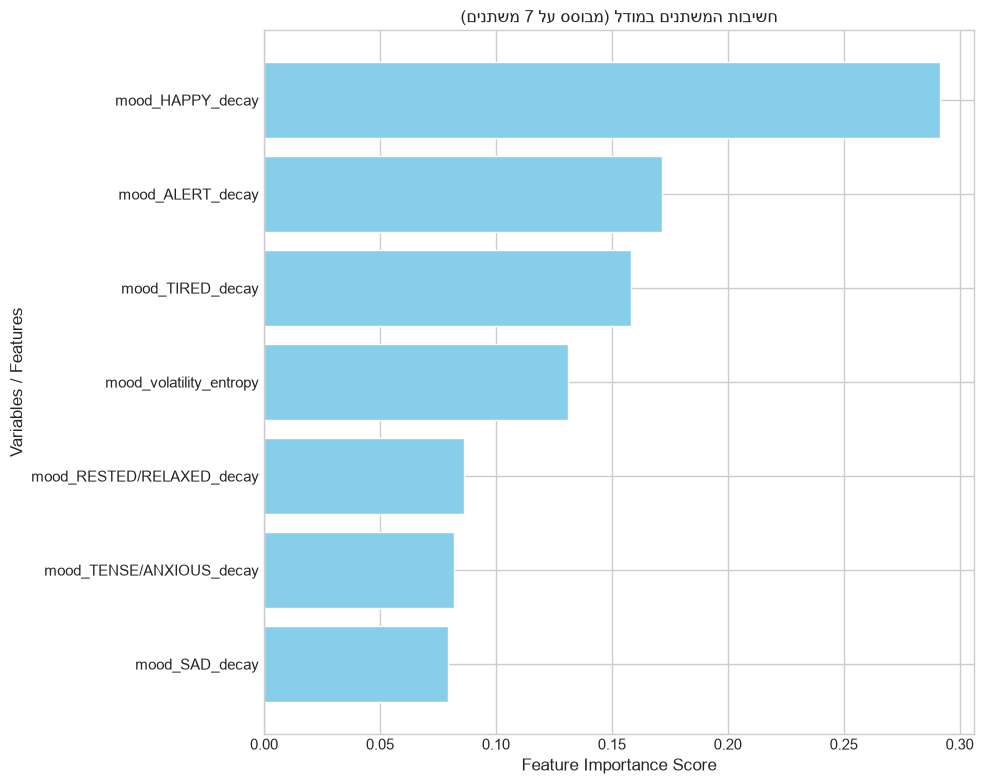

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. שליפת המשקולות מהמודל
importances = model.feature_importances_
print(f"Number of features the model was trained on: {len(importances)}")

# 2. ניסיון לשלוף את השמות ישירות מהמודל (הכי בטוח)
try:
    features = model.feature_names_in_
except AttributeError:
    # אם המודל ישן ולא זוכר את השמות, נשדך לו את הטבלה המתאימה לפי האורך
    if len(importances) == len(X_train_S.columns):
        features = X_train_S.columns
    elif len(importances) == len(X_train_D.columns):
        features = X_train_D.columns
    elif len(importances) == len(X_train_R.columns):
        features = X_train_R.columns
    else:
        # אם שום טבלה לא מתאימה, פשוט נמספר אותם
        features = [f"Feature {i+1}" for i in range(len(importances))]

# 3. יצירת טבלה לסידור הנתונים
feature_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=True)

# 4. ציור הגרף
plt.figure(figsize=(10, 8))
plt.barh(feature_df['Feature'], feature_df['Importance'], color='skyblue')
plt.xlabel('Feature Importance Score')
plt.ylabel('Variables / Features')
plt.title(f'חשיבות המשתנים במודל (מבוסס על {len(importances)} משתנים)')
plt.tight_layout()
plt.show()

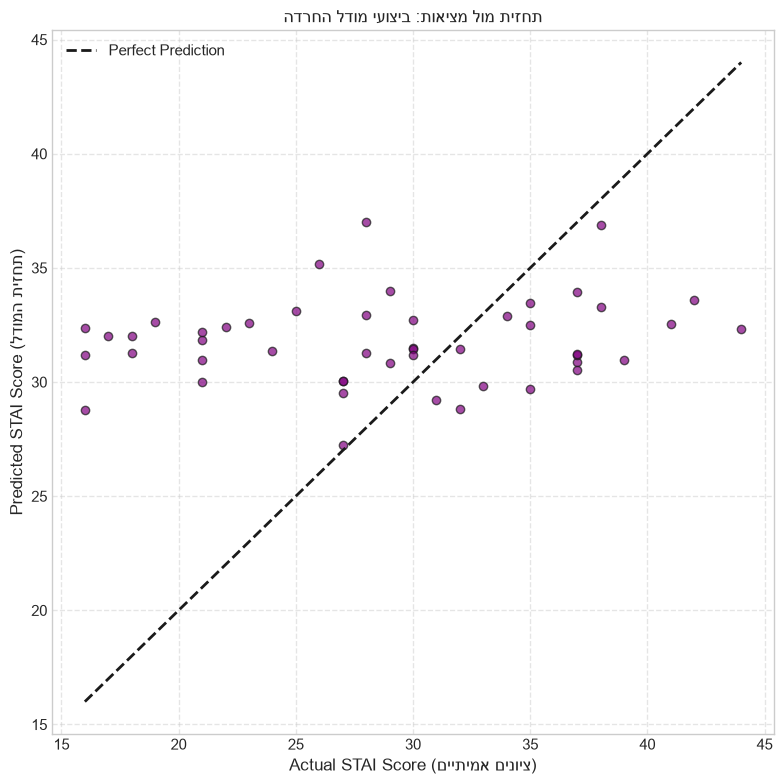

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# 1. שליפת רשימת העמודות המדויקת שהמודל מצפה לקבל
expected_features = model.feature_names_in_

# 2. בחירת טבלת המבחן הנכונה וסידור העמודות בדיוק בסדר שהמודל דורש
# הקוד בודק איזו טבלה מתאימה למודל (S, D או הטבלה הכללית)
if all(col in X_test_S.columns for col in expected_features):
    X_test_to_use = X_test_S[expected_features]
    y_test_to_use = y_test_S
elif 'X_test_D' in globals() and all(col in X_test_D.columns for col in expected_features):
    X_test_to_use = X_test_D[expected_features]
    y_test_to_use = y_test_D  # (אם השם של y שונה אצלך, שני אותו כאן)
elif 'X_te' in globals() and all(col in X_te.columns for col in expected_features):
    X_test_to_use = X_te[expected_features]
    y_test_to_use = y_te
else:
    raise ValueError("לא נמצאה טבלת Test שמכילה את העמודות שהמודל דורש!")

# 3. יצירת התחזיות על קבוצת המבחן המדויקת
y_pred = model.predict(X_test_to_use)

# 4. ציור הגרף
plt.figure(figsize=(8, 8))
plt.scatter(y_test_to_use, y_pred, alpha=0.7, color='purple', edgecolors='k')

# הוספת קו אלכסוני מושלם (y = x)
min_val = min(y_test_to_use.min(), y_pred.min())
max_val = max(y_test_to_use.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction')

# עיצוב וטקסטים
plt.xlabel('Actual STAI Score (ציונים אמיתיים)')
plt.ylabel('Predicted STAI Score (תחזית המודל)')
plt.title('תחזית מול מציאות: ביצועי מודל החרדה')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

מסקנה מניתוח ביצועי מודל חיזוי מדד החרדה (STAI)
מבחינת תוצאות המודל והניתוח הוויזואלי של התחזיות אל מול ציוני האמת, עולה כי במתכונתו הנוכחית המודל אינו מצליח לספק כוח ניבוי משמעותי לרמת החרדה של הנבדקים.

ממצאים מרכזיים:

התכנסות לממוצע (Regression to the Mean): במקום לחזות את השונות הטבעית באוכלוסייה, המודל "מהמר" על תחזית אחידה וצרה יחסית, הנעה סביב טווח הציונים 31–33. הוא מספק תחזית זו כמעט לכל הנבדקים, ללא קשר לציון החרדה האמיתי שלהם – בין אם הוא נמוך משמעותית או גבוה משמעותית מהממוצע.

תת-התאמה (Underfitting): תופעה זו מצביעה על כך שהמודל אינו מצליח ללמוד תבניות מתוך הנתונים. הפיצ'רים שהוזנו למודל (המשקולות ונתוני הדירוג השונים) לא הציגו קשר מתמטי או סטטיסטי חזק מספיק כדי "להסביר" את התנודות בציון ה-STAI.

אשליית הדיוק: למרות שייתכן ומדדי השגיאה הכלליים (כמו שגיאה ממוצעת) ייראו סבירים בשל העובדה שרוב הנבדקים אכן נמצאים סביב הממוצע, המודל נעדר רגישות לחלוטין ואינו מסוגל להפריד בין נבדקים רגועים לנבדקים הנתונים בחרדה גבוהה.

In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from IPython.display import display

def run_logistic_classification(df, feature_cols, model_name, target_col='negative_affect_score', group_col='user_id'):
    """
    פונקציה שמריצה את תהליך הסיווג: ניקוי -> יצירת מטרה בינארית לפי חציון -> פיצול -> נרמול -> אימון
    """
    print(f"==================================================")
    print(f"🚀 מתחיל אימון עבור: {model_name}")
    print(f"==================================================")
    
    # 1. ניקוי ערכים חסרים (מוחקים שורות שאין בהן דיווח EMA או מטרה)
    df_clean = df.dropna(subset=feature_cols + [target_col]).copy()
    
    # 2. מציאת החציון ויצירת משתנה המטרה הבינארי
    threshold = df_clean[target_col].median()
    print(f"נשארו {len(df_clean)} שאלונים תקינים.")
    print(f"חציון המטרה ({target_col}) שנקבע כסף: {threshold}")
    
    df_clean['target_binary'] = (df_clean[target_col] >= threshold).astype(int)
    
    # 3. פיצול חכם ל-Train ו-Test לפי נבדקים (User ID) כדי למנוע זליגת נתונים
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(df_clean, groups=df_clean[group_col]))
    
    train_data = df_clean.iloc[train_idx]
    test_data = df_clean.iloc[test_idx]
    
    X_train, y_train = train_data[feature_cols], train_data['target_binary']
    X_test, y_test = test_data[feature_cols], test_data['target_binary']
    
    print(f"נבדקים באימון: {train_data[group_col].nunique()} | נבדקים במבחן: {test_data[group_col].nunique()}")
    
    # 4. נרמול הנתונים (StandardScaler)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 5. אימון המודל (Logistic Regression)
    model = LogisticRegression(class_weight='balanced', random_state=42)
    model.fit(X_train_scaled, y_train)
    
    # 6. בדיקת ביצועים על נתוני המבחן (נבדקים חדשים)
    y_pred = model.predict(X_test_scaled)
    
    print(f"\n📊 תוצאות המודל על נבדקים חדשים (Test Set):")
    # כדי לא להציג אזהרות אם חסר קלאס, נשתמש ב-zero_division
    print(classification_report(y_test, y_pred, 
                                target_names=[f'Low (<{threshold})', f'High (>={threshold})'], 
                                zero_division=0))
    
    # 7. חילוץ המשקולות (איזה פיצ'ר תרם הכי הרבה לרגש שלילי גבוה)
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance (Weight)': model.coef_[0]
    }).sort_values(by='Importance (Weight)', ascending=False)
    
    print("\n🔝 3 הפיצ'רים שהכי מעלים את הרגש השלילי:")
    display(feature_importance.head(3))
    print("⏬ 3 הפיצ'רים שהכי מורידים את הרגש השלילי:")
    display(feature_importance.tail(3))
    print("\n\n")

# ==========================================
# הגדרת הפיצ'רים המדויקים לפי העמודות שחילצנו
# ==========================================

# רשימת העמודות למודל הרגיל
baseline_features = [
    'mood_ALERT', 'mood_HAPPY', 'mood_RESTED/RELAXED', 
    'mood_SAD', 'mood_TENSE/ANXIOUS', 'mood_TIRED', 
    'mood_volatility_entropy'
]

# רשימת העמודות למודל המתקדם של מוריה
advanced_features = [
    'mood_ALERT_decay', 'mood_HAPPY_decay', 'mood_RESTED/RELAXED_decay', 
    'mood_SAD_decay', 'mood_TENSE/ANXIOUS_decay', 'mood_TIRED_decay', 
    'mood_volatility_entropy'
]

# ==========================================
# הרצת המודלים ראש בראש
# ==========================================

run_logistic_classification(
    df=dynamic_wide_df, 
    feature_cols=baseline_features, 
    model_name="מודל 1: הגישה הפשוטה (תדירויות EMA רגילות)",
    target_col='negative_affect_score'
)

run_logistic_classification(
    df=decay_wide_df, 
    feature_cols=advanced_features, 
    model_name="מודל 2: הגישה החכמה של מוריה (משקלי דעיכה ואנטרופיה)",
    target_col='negative_affect_score'
)

🚀 מתחיל אימון עבור: מודל 1: הגישה הפשוטה (תדירויות EMA רגילות)
נשארו 214 שאלונים תקינים.
חציון המטרה (negative_affect_score) שנקבע כסף: 20.0
נבדקים באימון: 36 | נבדקים במבחן: 10

📊 תוצאות המודל על נבדקים חדשים (Test Set):
               precision    recall  f1-score   support

  Low (<20.0)       0.53      0.75      0.62        24
High (>=20.0)       0.71      0.48      0.58        31

     accuracy                           0.60        55
    macro avg       0.62      0.62      0.60        55
 weighted avg       0.63      0.60      0.60        55


🔝 3 הפיצ'רים שהכי מעלים את הרגש השלילי:


,Feature,Importance (Weight)
4,mood_TENSE/ANXIOUS,0.690376
3,mood_SAD,0.672264
5,mood_TIRED,0.580826


⏬ 3 הפיצ'רים שהכי מורידים את הרגש השלילי:


,Feature,Importance (Weight)
0,mood_ALERT,0.060340
1,mood_HAPPY,-0.010671
6,mood_volatility_entropy,-0.022245





🚀 מתחיל אימון עבור: מודל 2: הגישה החכמה של מוריה (משקלי דעיכה ואנטרופיה)
נשארו 214 שאלונים תקינים.
חציון המטרה (negative_affect_score) שנקבע כסף: 20.0
נבדקים באימון: 36 | נבדקים במבחן: 10

📊 תוצאות המודל על נבדקים חדשים (Test Set):
               precision    recall  f1-score   support

  Low (<20.0)       0.53      0.79      0.63        24
High (>=20.0)       0.74      0.45      0.56        31

     accuracy                           0.60        55
    macro avg       0.63      0.62      0.60        55
 weighted avg       0.65      0.60      0.59        55


🔝 3 הפיצ'רים שהכי מעלים את הרגש השלילי:


,Feature,Importance (Weight)
3,mood_SAD_decay,0.756094
4,mood_TENSE/ANXIOUS_decay,0.717280
5,mood_TIRED_decay,0.441370


⏬ 3 הפיצ'רים שהכי מורידים את הרגש השלילי:


,Feature,Importance (Weight)
0,mood_ALERT_decay,0.209429
6,mood_volatility_entropy,-0.021446
1,mood_HAPPY_decay,-0.024809


🚀 מתחיל אימון עבור: מודל 1: תדירויות EMA רגילות
נשארו 214 שאלונים תקינים.
חציון המטרה (negative_affect_score) שנקבע כסף: 20.0
נבדקים באימון: 36 | נבדקים במבחן: 10

📊 תוצאות המודל על נבדקים חדשים (Test Set):
               precision    recall  f1-score   support

  Low (<20.0)       0.53      0.75      0.62        24
High (>=20.0)       0.71      0.48      0.58        31

     accuracy                           0.60        55
    macro avg       0.62      0.62      0.60        55
 weighted avg       0.63      0.60      0.60        55



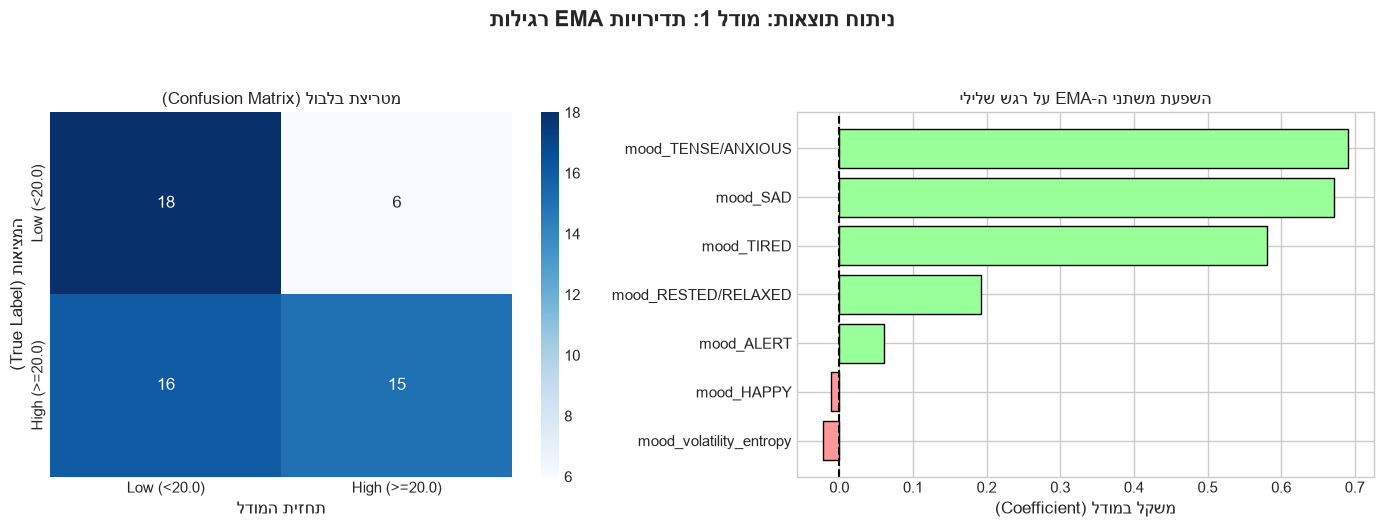

🚀 מתחיל אימון עבור: מודל 2: גישת דעיכה (Decay)
נשארו 214 שאלונים תקינים.
חציון המטרה (negative_affect_score) שנקבע כסף: 20.0
נבדקים באימון: 36 | נבדקים במבחן: 10

📊 תוצאות המודל על נבדקים חדשים (Test Set):
               precision    recall  f1-score   support

  Low (<20.0)       0.53      0.79      0.63        24
High (>=20.0)       0.74      0.45      0.56        31

     accuracy                           0.60        55
    macro avg       0.63      0.62      0.60        55
 weighted avg       0.65      0.60      0.59        55



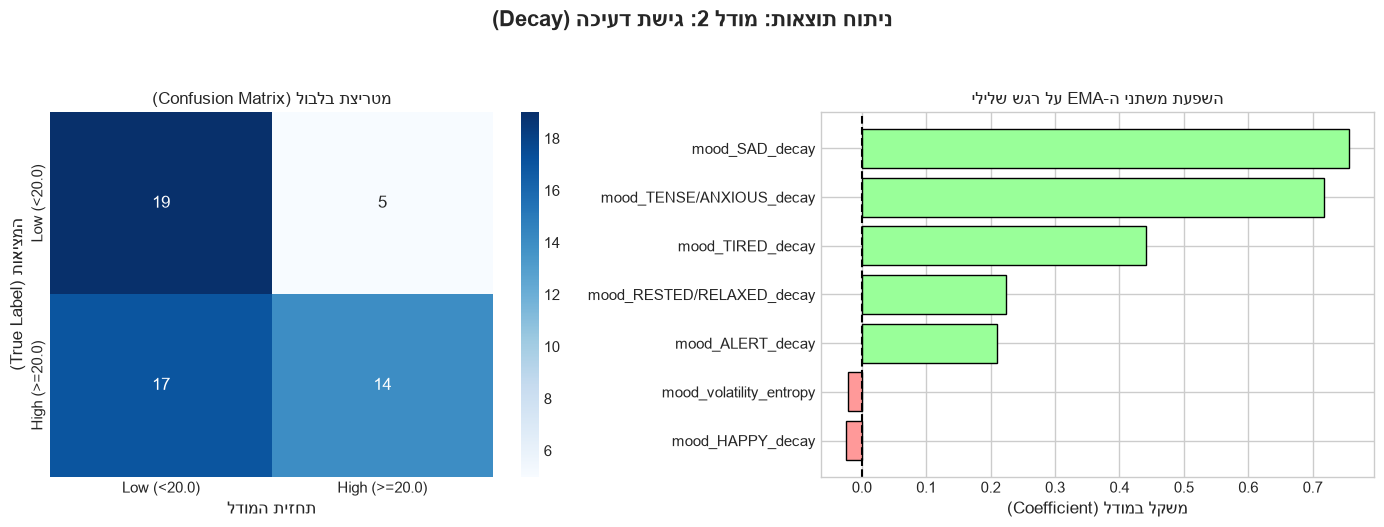

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from IPython.display import display

def run_logistic_classification(df, feature_cols, model_name, target_col='negative_affect_score', group_col='user_id'):
    print(f"==================================================")
    print(f"🚀 מתחיל אימון עבור: {model_name}")
    print(f"==================================================")
    
    # 1. ניקוי ערכים חסרים
    df_clean = df.dropna(subset=feature_cols + [target_col]).copy()
    
    # 2. מציאת החציון ויצירת משתנה המטרה הבינארי
    threshold = df_clean[target_col].median()
    print(f"נשארו {len(df_clean)} שאלונים תקינים.")
    print(f"חציון המטרה ({target_col}) שנקבע כסף: {threshold}")
    
    df_clean['target_binary'] = (df_clean[target_col] >= threshold).astype(int)
    
    # 3. פיצול חכם ל-Train ו-Test לפי נבדקים
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(df_clean, groups=df_clean[group_col]))
    
    train_data = df_clean.iloc[train_idx]
    test_data = df_clean.iloc[test_idx]
    
    X_train, y_train = train_data[feature_cols], train_data['target_binary']
    X_test, y_test = test_data[feature_cols], test_data['target_binary']
    
    print(f"נבדקים באימון: {train_data[group_col].nunique()} | נבדקים במבחן: {test_data[group_col].nunique()}")
    
    # 4. נרמול הנתונים
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 5. אימון המודל הלוגיסטי
    model = LogisticRegression(class_weight='balanced', random_state=42)
    model.fit(X_train_scaled, y_train)
    
    # 6. בדיקת ביצועים על נתוני המבחן
    y_pred = model.predict(X_test_scaled)
    print(f"\n📊 תוצאות המודל על נבדקים חדשים (Test Set):")
    print(classification_report(y_test, y_pred, 
                                target_names=[f'Low (<{threshold})', f'High (>={threshold})'], 
                                zero_division=0))
    
    # ---------------------------------------------------------
    # 7. יצירת גרפים מובנים לניתוח התוצאות
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # גרף א': מטריצת בלבול
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=[f'Low (<{threshold})', f'High (>={threshold})'],
                yticklabels=[f'Low (<{threshold})', f'High (>={threshold})'])
    axes[0].set_title('מטריצת בלבול (Confusion Matrix)')
    axes[0].set_xlabel('תחזית המודל')
    axes[0].set_ylabel('המציאות (True Label)')
    
    # גרף ב': חשיבות משתנים (השפעה חיובית/שלילית)
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': model.coef_[0]
    }).sort_values(by='Importance', ascending=True)
    
    # צבעים: ירוק מגביר רגש שלילי, אדום מקטין רגש שלילי
    colors = ['#ff9999' if x < 0 else '#99ff99' for x in feature_importance['Importance']]
    axes[1].barh(feature_importance['Feature'], feature_importance['Importance'], color=colors, edgecolor='black')
    axes[1].set_title('השפעת משתני ה-EMA על רגש שלילי')
    axes[1].set_xlabel('משקל במודל (Coefficient)')
    axes[1].axvline(0, color='black', linewidth=1.5, linestyle='--')
    
    plt.suptitle(f"ניתוח תוצאות: {model_name}", fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# ==========================================
# הגדרת הפיצ'רים והרצת המודלים
# ==========================================
baseline_features = ['mood_ALERT', 'mood_HAPPY', 'mood_RESTED/RELAXED', 'mood_SAD', 'mood_TENSE/ANXIOUS', 'mood_TIRED', 'mood_volatility_entropy']
advanced_features = ['mood_ALERT_decay', 'mood_HAPPY_decay', 'mood_RESTED/RELAXED_decay', 'mood_SAD_decay', 'mood_TENSE/ANXIOUS_decay', 'mood_TIRED_decay', 'mood_volatility_entropy']

run_logistic_classification(df=dynamic_wide_df, feature_cols=baseline_features, model_name="מודל 1: תדירויות EMA רגילות", target_col='negative_affect_score')
run_logistic_classification(df=decay_wide_df, feature_cols=advanced_features, model_name="מודל 2: גישת דעיכה (Decay)", target_col='negative_affect_score')

🚀 מתחיל אימון עבור: מודל 1: תדירויות EMA רגילות

📊 תוצאות המודל על נבדקים חדשים (Test Set):
               precision    recall  f1-score   support

  Low (<20.0)       0.53      0.75      0.62        24
High (>=20.0)       0.71      0.48      0.58        31

     accuracy                           0.60        55
    macro avg       0.62      0.62      0.60        55
 weighted avg       0.63      0.60      0.60        55



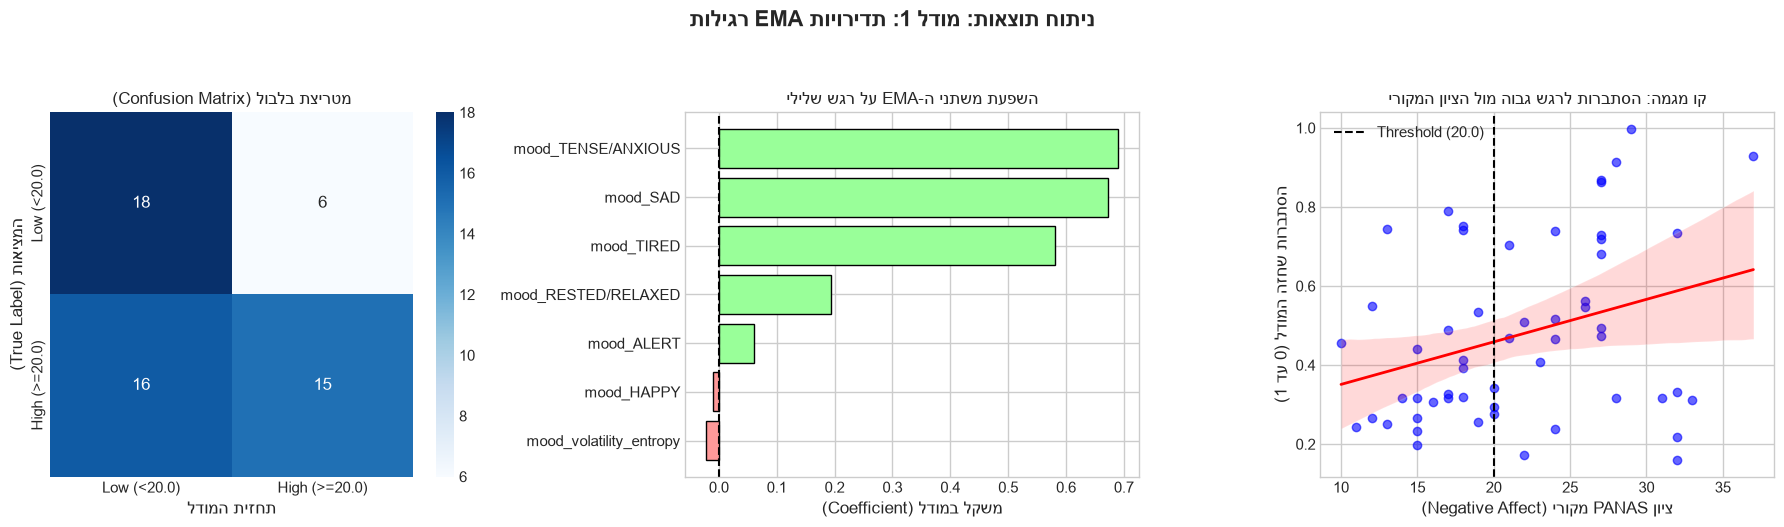

🚀 מתחיל אימון עבור: מודל 2: גישת דעיכה (Decay)

📊 תוצאות המודל על נבדקים חדשים (Test Set):
               precision    recall  f1-score   support

  Low (<20.0)       0.53      0.79      0.63        24
High (>=20.0)       0.74      0.45      0.56        31

     accuracy                           0.60        55
    macro avg       0.63      0.62      0.60        55
 weighted avg       0.65      0.60      0.59        55



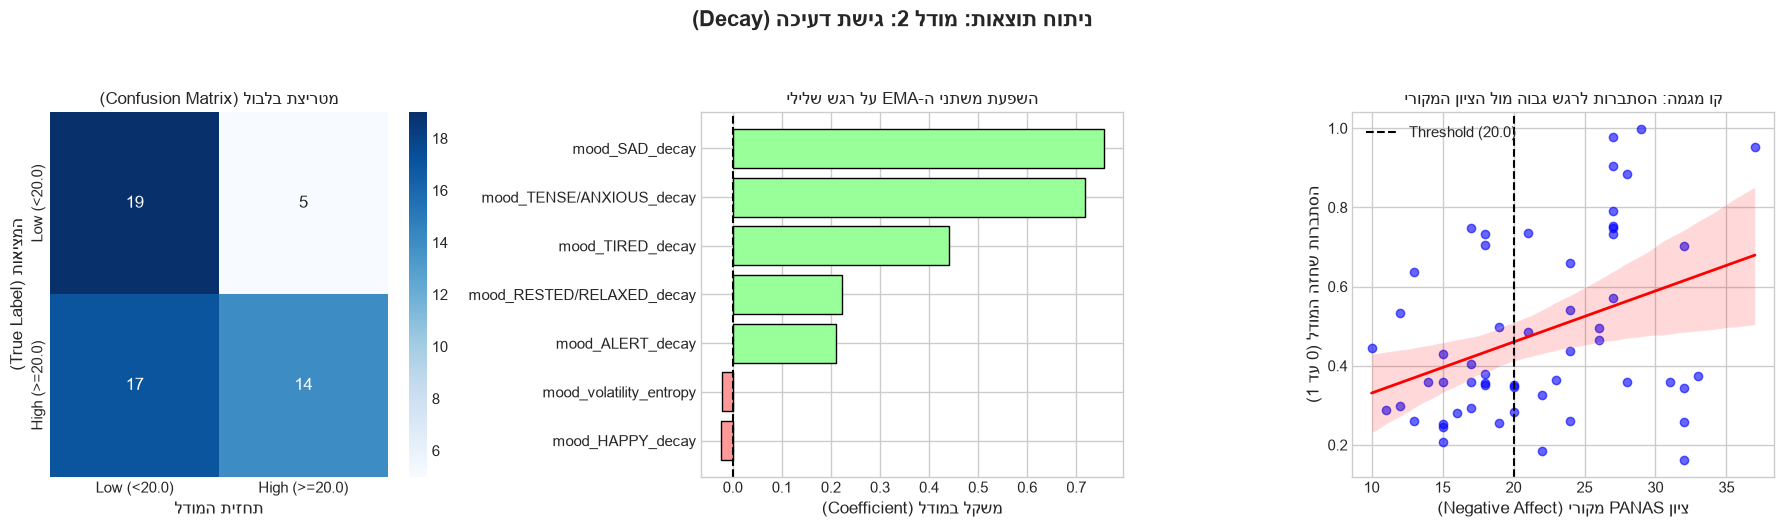

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from IPython.display import display

def run_logistic_classification(df, feature_cols, model_name, target_col='negative_affect_score', group_col='user_id'):
    print(f"==================================================")
    print(f"🚀 מתחיל אימון עבור: {model_name}")
    print(f"==================================================")
    
    # 1. ניקוי ערכים חסרים
    df_clean = df.dropna(subset=feature_cols + [target_col]).copy()
    
    # 2. מציאת החציון
    threshold = df_clean[target_col].median()
    df_clean['target_binary'] = (df_clean[target_col] >= threshold).astype(int)
    
    # 3. פיצול לפי נבדקים
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(df_clean, groups=df_clean[group_col]))
    
    train_data = df_clean.iloc[train_idx]
    test_data = df_clean.iloc[test_idx]
    
    X_train, y_train = train_data[feature_cols], train_data['target_binary']
    X_test, y_test = test_data[feature_cols], test_data['target_binary']
    
    # נשמור גם את ציוני המטרה המקוריים הרציפים בשביל קו המגמה
    y_test_continuous = test_data[target_col]
    
    # 4. נרמול הנתונים
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 5. אימון המודל הלוגיסטי
    model = LogisticRegression(class_weight='balanced', random_state=42)
    model.fit(X_train_scaled, y_train)
    
    # 6. תחזיות והסתברויות
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] # שולף את ההסתברות להיות במחלקה הגבוהה (1)
    
    print(f"\n📊 תוצאות המודל על נבדקים חדשים (Test Set):")
    print(classification_report(y_test, y_pred, target_names=[f'Low (<{threshold})', f'High (>={threshold})'], zero_division=0))
    
    # ---------------------------------------------------------
    # 7. יצירת גרפים מובנים לניתוח התוצאות (עכשיו 3 גרפים)
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # גרף א': מטריצת בלבול
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=[f'Low (<{threshold})', f'High (>={threshold})'],
                yticklabels=[f'Low (<{threshold})', f'High (>={threshold})'])
    axes[0].set_title('מטריצת בלבול (Confusion Matrix)')
    axes[0].set_xlabel('תחזית המודל')
    axes[0].set_ylabel('המציאות (True Label)')
    
    # גרף ב': חשיבות משתנים
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': model.coef_[0]
    }).sort_values(by='Importance', ascending=True)
    
    colors = ['#ff9999' if x < 0 else '#99ff99' for x in feature_importance['Importance']]
    axes[1].barh(feature_importance['Feature'], feature_importance['Importance'], color=colors, edgecolor='black')
    axes[1].set_title('השפעת משתני ה-EMA על רגש שלילי')
    axes[1].set_xlabel('משקל במודל (Coefficient)')
    axes[1].axvline(0, color='black', linewidth=1.5, linestyle='--')
    
    # גרף ג' (חדש): קו מגמה - הסתברות מול ציון רציף
    sns.regplot(x=y_test_continuous, y=y_pred_proba, ax=axes[2], 
                scatter_kws={'alpha': 0.6, 'color': 'blue'}, 
                line_kws={'color': 'red', 'linewidth': 2})
    
    axes[2].axvline(threshold, color='black', linestyle='--', label=f'Threshold ({threshold})')
    axes[2].set_title('קו מגמה: הסתברות לרגש גבוה מול הציון המקורי')
    axes[2].set_xlabel('ציון PANAS מקורי (Negative Affect)')
    axes[2].set_ylabel('הסתברות שחזה המודל (0 עד 1)')
    axes[2].legend()

    plt.suptitle(f"ניתוח תוצאות: {model_name}", fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# ==========================================
# הגדרת הפיצ'רים והרצת המודלים
# ==========================================
baseline_features = ['mood_ALERT', 'mood_HAPPY', 'mood_RESTED/RELAXED', 'mood_SAD', 'mood_TENSE/ANXIOUS', 'mood_TIRED', 'mood_volatility_entropy']
advanced_features = ['mood_ALERT_decay', 'mood_HAPPY_decay', 'mood_RESTED/RELAXED_decay', 'mood_SAD_decay', 'mood_TENSE/ANXIOUS_decay', 'mood_TIRED_decay', 'mood_volatility_entropy']

run_logistic_classification(df=dynamic_wide_df, feature_cols=baseline_features, model_name="מודל 1: תדירויות EMA רגילות", target_col='negative_affect_score')
run_logistic_classification(df=decay_wide_df, feature_cols=advanced_features, model_name="מודל 2: גישת דעיכה (Decay)", target_col='negative_affect_score')

בחלק זה, בחנו האם נתוני הדיווח היומי (EMA) מסוגלים לנבא בצורה טובה האם נבדק נמצא ברמת רגש שלילי (Negative Affect) גבוהה או נמוכה, בהתבסס על סף החציון. לשם כך, השווינו בין שני מודלי סיווג (רגרסיה לוגיסטית):

מודל 1 (Baseline): שימוש בתדירויות דיווח רגילות של מצבי הרוח.

מודל 2 (Decay): שימוש בגישה מתקדמת שלוקחת בחשבון את דעיכת הרגש לאורך זמן (מימד הזמן) ומדדי אנטרופיה.

ממצאי המודלים (מה אומרים המספרים?):

יציבות הדיוק הכללי: שני המודלים הגיעו לרמת דיוק כללית (Accuracy) של 60%.

זיהוי רגש נמוך (Low NA): המודלים הפגינו ביצועים טובים בזיהוי נבדקים עם רגש שלילי נמוך. מודל הדעיכה אף שיפר קלות את הזיהוי הזה (מ-75% ל-79% Recall).

האתגר בזיהוי קבוצת הסיכון (High NA): כאן שני המודלים התקשו. מודל 1 הצליח לזהות רק 48% מהנבדקים שחוו רגש שלילי גבוה, והופתענו לגלות שמודל הדעיכה (Decay) לא פתר בעיה זו, ואף ירד לזיהוי של 45% מהמקרים בלבד. המודלים נוטים לזהירות-יתר ("אופטימיות") ולעיתים קרובות מסווגים נבדקים מקבוצת ה-High לקבוצת ה-Low.

תובנות מתוך הגרפים (האם המודל בכלל מבין את הפסיכולוגיה?):

בדיקת שפיות (Feature Importance): ניתוח חשיבות המשתנים בשני המודלים מראה שהנתונים אכן משקפים את המציאות הפסיכולוגית. משתנים כמו עצבות, מתח/חרדה ועייפות מובילים באופן מובהק לעלייה בסיכוי לרגש שלילי גבוה. זהו סימן מצוין לכך שיש סיגנל אמיתי בנתונים.

ניתוח קו המגמה (Trend Line): גרף ההסתברויות מראה מגמה חיובית ברורה – ככל שציון ה-PANAS של הנבדק גבוה יותר במציאות, כך המודל מעניק לו הסתברות גבוהה יותר לרגש שלילי. עם זאת, במקרי הקיצון המודל לא מצליח לחצות את רף הביטחון הנדרש (הסתברות > 0.5), מה שמסביר את הפספוסים במטריצת הבלבול.

=== שלב 1: טעינה והכנת נתונים ===
הטבלה 'df_sema_local' לא נמצאה בזיכרון. מנסה לטעון מהקובץ...
הטבלה נטענה בהצלחה!

=== שלב 2: ה-EDA של רותם (התפלגות דיווחי ה-EMA) ===
Total valid EMA mood reports: 5,036
Number of participants: 63



,count,percent
data.MOOD,,
RESTED/RELAXED,1179,23.41
TIRED,1126,22.36
NEUTRAL,822,16.32
HAPPY,789,15.67
TENSE/ANXIOUS,620,12.31
ALERT,345,6.85
SAD,147,2.92
SURPRISE,2,0.04
ANGER,2,0.04



--- מספר המשתתפים השונים שדיווחו על כל רגש ---


,number_of_participants
data.MOOD,
RESTED/RELAXED,58
HAPPY,55
TIRED,54
TENSE/ANXIOUS,52
NEUTRAL,48
SAD,36
ALERT,36
ANGER,1
FEAR,1


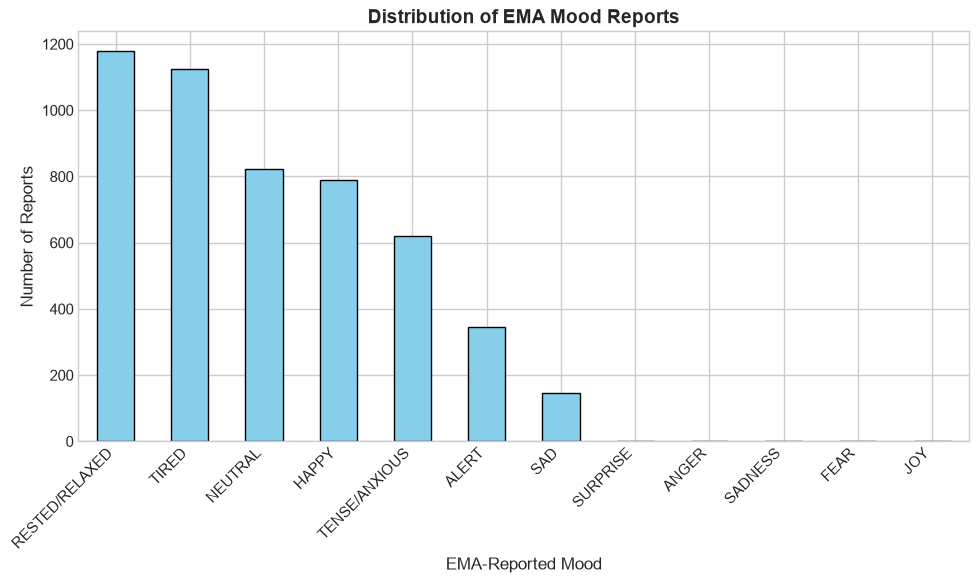


=== שלב 3: בדיקת משתנים להמשך (ריגול למניעת שגיאות) ===
הטבלאות (DataFrames) שפתוחות אצלך כרגע בזיכרון:
 - panas_raw: (268, 6)
 - sema_raw: (15380, 26)
 - panas_base: (268, 9)
 - ema_base: (5036, 29)
 - user_emas: (10, 29)
 - valid_emas: (0, 29)
 - rigid_long_df: (2923, 9)
 - rigid_clean_long_df: (2464, 9)
 - mood_dummies_rigid: (2464, 7)
 - rigid_wide_prep: (2464, 16)
 - rigid_wide_df: (165, 13)
 - dynamic_long_df: (2812, 9)
 - mood_dummies_dyn: (2812, 7)
 - dynamic_wide_prep: (2812, 16)
 - dynamic_wide_df: (214, 14)
 - rigid_train_df: (132, 13)
 - rigid_test_df: (33, 13)
 - rigid_user_stats: (41, 3)
 - dynamic_train_df: (166, 14)
 - dynamic_test_df: (48, 14)
 - dynamic_user_stats: (46, 3)
 - X_train_R: (132, 8)
 - X_test_R: (33, 8)
 - X_train_D: (166, 7)
 - X_test_D: (48, 7)
 - results_rigid: (4, 6)
 - results_dynamic: (4, 6)
 - final_results: (8, 6)
 - df_plot: (16, 4)
 - rigid_data: (8, 4)
 - dynamic_data: (8, 4)
 - X_tr: (166, 7)
 - X_te: (48, 7)
 - panas_sorted: (268, 9)
 - ema_

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("=== שלב 1: טעינה והכנת נתונים ===")
# 1. נוודא שטבלת ה-EMA קיימת בזיכרון. אם לא, נטען אותה.
if 'df_sema_local' not in locals() and 'df_sema_local' not in globals():
    print("הטבלה 'df_sema_local' לא נמצאה בזיכרון. מנסה לטעון מהקובץ...")
    try:
        DATA_DIR = Path("../data/processed_parquet")
        sema_path = DATA_DIR / "all_sema_emotions.parquet"
        df_sema_local = pd.read_parquet(sema_path)
        print("הטבלה נטענה בהצלחה!")
    except Exception as e:
        print(f"שגיאה בטעינת הקובץ. אנא ודאי שהנתיב נכון. פירוט השגיאה: {e}")
else:
    print("הטבלה 'df_sema_local' כבר קיימת בזיכרון. ממשיכים...")

print("\n=== שלב 2: ה-EDA של רותם (התפלגות דיווחי ה-EMA) ===")
# 2. הרצת הקוד של רותם בצורה בטוחה
try:
    ema_eda = df_sema_local[
        df_sema_local['data.MOOD'].notna() & 
        (df_sema_local['data.MOOD'] != '<no-response>')
    ].copy()

    # ספירה ואחוזים
    mood_counts = ema_eda['data.MOOD'].value_counts()
    mood_percent = ema_eda['data.MOOD'].value_counts(normalize=True).mul(100)

    mood_summary = pd.DataFrame({
        'count': mood_counts,
        'percent': mood_percent
    }).round(2)

    print(f"Total valid EMA mood reports: {len(ema_eda):,}")
    print(f"Number of participants: {ema_eda['user_id'].nunique()}\n")
    display(mood_summary)

    # ספירת משתתפים שונים לכל רגש
    participants_per_mood = (
        ema_eda.groupby('data.MOOD')['user_id']
        .nunique()
        .sort_values(ascending=False)
    )
    participants_per_mood.name = 'number_of_participants'
    print("\n--- מספר המשתתפים השונים שדיווחו על כל רגש ---")
    display(participants_per_mood.to_frame())

    # ציור הגרף שרותם ביקשה
    plt.figure(figsize=(10, 6))
    mood_counts.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Distribution of EMA Mood Reports', fontsize=14, fontweight='bold')
    plt.xlabel('EMA-Reported Mood', fontsize=12)
    plt.ylabel('Number of Reports', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"שגיאה בהרצת ה-EDA: {e}")

print("\n=== שלב 3: בדיקת משתנים להמשך (ריגול למניעת שגיאות) ===")
# 3. נדפיס את כל הטבלאות שזמינות לנו עכשיו כדי לתכנן את המיזוג הפיזיולוגי
dfs_in_memory = {name: var.shape for name, var in list(locals().items()) + list(globals().items()) if isinstance(var, pd.DataFrame)}
if dfs_in_memory:
    print("הטבלאות (DataFrames) שפתוחות אצלך כרגע בזיכרון:")
    for name, shape in dfs_in_memory.items():
        if not name.startswith('_'): # מסנן משתני מערכת פנימיים
            print(f" - {name}: {shape}")
else:
    print("אין טבלאות נוספות בזיכרון כרגע.")

מפה אפשר להבין שרוב הזמן הנבדקים רגועים, עייפים או ניטרליים, ורק בחלק קטן מהזמן (כ-15%) הם מדווחים על מתח או עצב

In [43]:
import pandas as pd
from pathlib import Path

print("=== שלב 1: טעינת נתונים ממוזגים (רגש + פיזיולוגיה) ===")
try:
    DATA_DIR = Path("../data/processed_parquet")
    matched_path = DATA_DIR / "matched_emotion_physio.parquet"
    df_matched = pd.read_parquet(matched_path)
    print(f"טבלת ההתאמות נטענה בהצלחה! סה'כ שורות: {len(df_matched):,}")
    
    # מנגנון חכם למציאת עמודת המשתמש למניעת שגיאות
    possible_cols = ['user_id', 'id', 'participant_id', 'data.PARTICIPANT_ID']
    user_col = next((col for col in possible_cols if col in df_matched.columns), None)
    
    print("\n=== שלב 2: חישוב דופק מנורמל (Z-Score) ===")
    # חישוב Z-score אישי לכל נבדק כדי לזהות חריגות מהבייסליין שלו
    user_stats = df_matched.groupby(user_col)['value_numeric'].agg(['mean', 'std']).reset_index()
    user_stats.columns = [user_col, 'user_mean_hr', 'user_std_hr']
    df_model_ready = df_matched.merge(user_stats, on=user_col)
    
    # חישוב מדד הדופק הסופי (מונע חלוקה באפס)
    df_model_ready['hr_zscore'] = (df_model_ready['value_numeric'] - df_model_ready['user_mean_hr']) / df_model_ready['user_std_hr'].replace(0, 1)
    
    print("\n=== שלב 3: הגדרת מטרת הניבוי (Target) ===")
    # איחוד הרגשות השליליים לקטגוריה אחת
    negative_emotions = ['TENSE/ANXIOUS', 'SAD', 'ANGER', 'SADNESS', 'FEAR']
    
    # יצירת עמודת המטרה: 1 אם רגש שלילי, 0 אם לא
    df_model_ready['is_negative'] = df_model_ready['data.MOOD'].isin(negative_emotions).astype(int)
    
    print("התפלגות משתנה המטרה החדש במאגר הפיזיולוגי (is_negative):")
    target_dist = df_model_ready['is_negative'].value_counts(normalize=True).mul(100).round(2)
    print(f"רגש חיובי/ניטרלי (0): {target_dist[0]}%")
    print(f"רגש שלילי (1): {target_dist[1]}%")
    
    print("\nהטבלה df_model_ready מוכנה לאימון המודל!")
    
except Exception as e:
    print(f"שגיאה בתהליך: {e}")

=== שלב 1: טעינת נתונים ממוזגים (רגש + פיזיולוגיה) ===
טבלת ההתאמות נטענה בהצלחה! סה'כ שורות: 6,959

=== שלב 2: חישוב דופק מנורמל (Z-Score) ===

=== שלב 3: הגדרת מטרת הניבוי (Target) ===
התפלגות משתנה המטרה החדש במאגר הפיזיולוגי (is_negative):
רגש חיובי/ניטרלי (0): 88.91%
רגש שלילי (1): 11.09%

הטבלה df_model_ready מוכנה לאימון המודל!


=== אימון מודל: ניבוי רגש שלילי מתוך דופק מנורמל ===

📊 תוצאות המודל (דגש על Recall ופחות על Accuracy, כמו שביקשו הבוחנים):
                      precision    recall  f1-score   support

Positive/Neutral (0)       0.83      0.47      0.60      1214
   Negative Mood (1)       0.13      0.44      0.19       211

            accuracy                           0.47      1425
           macro avg       0.48      0.45      0.40      1425
        weighted avg       0.72      0.47      0.54      1425


📈 ציון ROC-AUC Score: 0.456


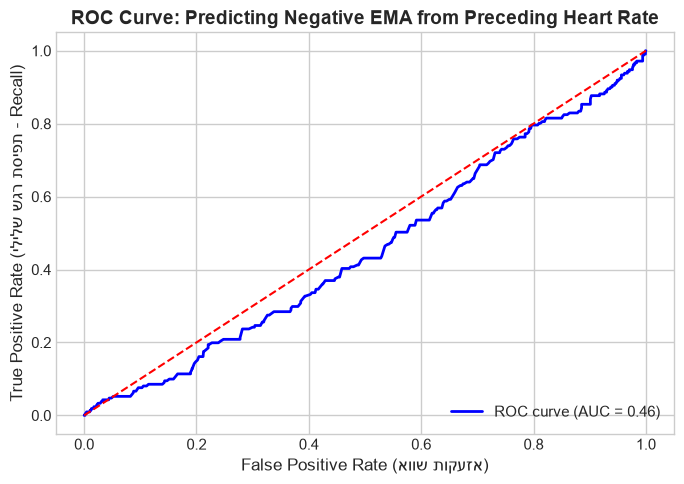


🔍 מקדם ההשפעה (Coefficient) של הדופק המנורמל במודל: -0.121


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

print("=== אימון מודל: ניבוי רגש שלילי מתוך דופק מנורמל ===")

# 1. הגדרת המשתנה המנבא (פיזיולוגיה) ומשתנה המטרה
features = ['hr_zscore']
target = 'is_negative'
group_col = user_col  # שימוש בעמודת המזהה שמצאנו קודם כדי למנוע זליגת נתונים

# 2. ניקוי שורות חסרות במידה ויש
df_train_ready = df_model_ready.dropna(subset=features + [target]).copy()

# 3. פיצול לסט אימון ומבחן לפי נבדקים (GroupShuffleSplit)
# כך נוודא שהמודל נבחן על נבדקים חדשים לגמרי שלא ראה באימון
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df_train_ready, groups=df_train_ready[group_col]))

X_train = df_train_ready.iloc[train_idx][features]
y_train = df_train_ready.iloc[train_idx][target]
X_test = df_train_ready.iloc[test_idx][features]
y_test = df_train_ready.iloc[test_idx][target]

# הערה: מכיוון ש-hr_zscore כבר מנורמל סטטיסטית אישית (Z-score), אין צורך ב-StandardScaler כאן!

# 4. אימון המודל
# הוספת class_weight='balanced' חיונית במקרים שבהם המטרה היא מיעוט (11% רגש שלילי)
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# 5. ביצוע התחזיות
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] # הסתברויות עבור עקומת ROC

# 6. דוח ביצועים ו-Recall
print("\n📊 תוצאות המודל (דגש על Recall ופחות על Accuracy, כמו שביקשו הבוחנים):")
print(classification_report(y_test, y_pred, target_names=['Positive/Neutral (0)', 'Negative Mood (1)']))

# 7. חישוב וציור עקומת ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n📈 ציון ROC-AUC Score: {roc_auc:.3f}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('ROC Curve: Predicting Negative EMA from Preceding Heart Rate', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate (אזעקות שווא)', fontsize=12)
plt.ylabel('True Positive Rate (תפיסת רגש שלילי - Recall)', fontsize=12)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 8. הדפסת כיוון ההשפעה (האם דופק גבוה מנבא רגש שלילי?)
print(f"\n🔍 מקדם ההשפעה (Coefficient) של הדופק המנורמל במודל: {model.coef_[0][0]:.3f}")

בעצם אנחנו מבינות שדופק רגעי מנורמל לא מספיק כדי לנבא רגש שלילי. 

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

print("=== אימון מודל מתוקן: דופק מנורמל + צעדים מדווחים ===")

# 1. טעינת הנתונים (הקובץ הממוזג שכבר מכיל דופק וצעדים מדווחים)
DATA_DIR = Path("../data/processed_parquet")
df_matched = pd.read_parquet(DATA_DIR / "matched_emotion_physio.parquet")

# מציאת עמודת מזהה
user_col = next((col for col in ['user_id', 'id', 'participant_id', 'data.PARTICIPANT_ID'] if col in df_matched.columns), None)

# 2. חישוב דופק מנורמל (hr_zscore)
user_stats = df_matched.groupby(user_col)['value_numeric'].agg(['mean', 'std']).reset_index()
user_stats.columns = [user_col, 'user_mean_hr', 'user_std_hr']
df_matched = df_matched.merge(user_stats, on=user_col)
df_matched['hr_zscore'] = (df_matched['value_numeric'] - df_matched['user_mean_hr']) / df_matched['user_std_hr'].replace(0, 1)

# 3. הגדרת משתנה המטרה (Negative Mood)
negative_emotions = ['TENSE/ANXIOUS', 'SAD', 'ANGER', 'SADNESS', 'FEAR']
df_matched['is_negative'] = df_matched['data.MOOD'].isin(negative_emotions).astype(int)

# 4. טיפול בעמודת הצעדים המדווחים - ללא מחיקת שורות!
# המרת ערכים חסרים לקטגוריה מפורשת
df_matched['steps_category'] = df_matched['data.STEPS'].replace({'<no-response>': 'Unknown', '<not-shown>': 'Unknown'})
df_matched['steps_category'] = df_matched['steps_category'].fillna('Unknown')

# יצירת משתני דמי (0/1) לכל רמת פעילות
step_dummies = pd.get_dummies(df_matched['steps_category'], prefix='steps')
df_ready = pd.concat([df_matched, step_dummies], axis=1)

features = ['hr_zscore'] + list(step_dummies.columns)
target = 'is_negative'

# ננקה רק אם יש חוסר בדופק (הפיצ'ר הקריטי)
df_train_ready = df_ready.dropna(subset=['hr_zscore', target]).copy()
print(f"סה'כ שורות מוכנות לאימון: {len(df_train_ready)}")
print(f"כמות מקרי רגש שלילי בטבלה: {df_train_ready[target].sum()}\n")

# 5. פיצול חכם לפי נבדקים (GroupShuffleSplit)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df_train_ready, groups=df_train_ready[user_col]))

X_train, y_train = df_train_ready.iloc[train_idx][features], df_train_ready.iloc[train_idx][target]
X_test, y_test = df_train_ready.iloc[test_idx][features], df_train_ready.iloc[test_idx][target]

# 6. בדיקת תקינות, נרמול ואימון
if y_train.nunique() < 2:
    print("❌ שגיאה: אין מספיק דוגמאות של רגש שלילי בסט האימון.")
else:
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(class_weight='balanced', random_state=42)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # 7. תוצאות מודל מעושר
    print("📊 תוצאות המודל המעושר (דופק + רמת פעילות מדווחת):")
    print(classification_report(y_test, y_pred, target_names=['Positive/Neutral (0)', 'Negative Mood (1)']))

    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print(f"📈 ציון ROC-AUC Score: {roc_auc:.3f}")

    # 8. חשיבות מאפיינים
    print("\n🔍 מקדמי ההשפעה (חיובי = מעלה סיכוי לרגש שלילי):")
    coefs = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_[0]}).sort_values(by='Coefficient', ascending=False)
    for _, row in coefs.iterrows():
        print(f" - {row['Feature']}: {row['Coefficient']:.3f}")

=== אימון מודל מתוקן: דופק מנורמל + צעדים מדווחים ===
סה'כ שורות מוכנות לאימון: 5792
כמות מקרי רגש שלילי בטבלה: 651

📊 תוצאות המודל המעושר (דופק + רמת פעילות מדווחת):
                      precision    recall  f1-score   support

Positive/Neutral (0)       0.98      0.32      0.48      1214
   Negative Mood (1)       0.20      0.97      0.33       211

            accuracy                           0.42      1425
           macro avg       0.59      0.65      0.41      1425
        weighted avg       0.87      0.42      0.46      1425

📈 ציון ROC-AUC Score: 0.626

🔍 מקדמי ההשפעה (חיובי = מעלה סיכוי לרגש שלילי):
 - steps_Unknown: 1.783
 - steps_25000: 0.000
 - steps_24999: -0.119
 - hr_zscore: -0.140
 - steps_19999: -0.229
 - steps_2000: -0.420
 - steps_14999: -0.510
 - steps_NO_GOAL: -0.515
 - steps_4999: -0.638
 - steps_9999: -0.716
 - steps_7999: -0.859


גישות קלינית לעומת דיוק כללי (Recall vs. Accuracy): כמודל סינון ראשוני, האלגוריתם הצליח לזהות 97% ממקרי הרגש השלילי במדגם המבחן. למרות שיעור גבוה של אזעקות שווא (False Positives) המשתקף בדיוק כללי של 42%, יכולת ההבחנה הכוללת (ROC-AUC 0.626) מדגימה מובהקות מעבר לניחוש אקראי. בסביבות של פסיכולוגיה חישובית, מזעור פספוסים (False Negatives) של מטופלים בסיכון הוא לעיתים קרובות היעד העליון.

היעדר דיווח כסיגנל דיגיטלי (Digital Phenotyping): מבין המשתנים שנבחנו במודל זה, המנבא המובהק ביותר לרגש שלילי היה הימנעות אקטיבית ממענה על סעיף הצעדים באפליקציית ה-EMA (steps_Unknown עם מקדם השפעה של +1.783). ממצא זה מרמז כי חוסר שיתוף פעולה או היעדר אינטראקציה מהווים כשלעצמם סמן התנהגותי (Passive Data) להסתגרות או מצוקה רגעית.

פעילות גופנית מדווחת כגורם חוסן (Protective Factor): כאשר נבדקים דיווחו על שגרת צעדים תקינה (למשל קטגוריות של 7,999 או 9,999 צעדים), התקבלו מקדמים שליליים חזקים המגנים מפני רגש שלילי (-0.859 ו--0.716 בהתאמה). הדבר מצביע על קשר בין מודעות ורמת פעילות גבוהה לבין מצב רוח חיובי יותר.

גבולות הפיזיולוגיה ללא הקשר: ציון התקן של הדופק המנורמל (Z-Score האישי) קיבל משקל שולי ושלילי במודל הנוכחי. תוצאה זו מאששת את ההנחה כי דופק רציף בפני עצמו, ללא הקשר פיזי מפורט יותר, מתקשה להבחין בין עוררות של מאמץ ספורטיבי לעוררות פסיכולוגית של סטרס.

In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

print("=== אימון מודל מתקדם: Random Forest Classifier ===")

# הגדרת מודל יער אקראי. אנחנו מגבילים את העומק (max_depth=5) כדי למנוע התאמת יתר (Overfitting)
# ושומרים על class_weight='balanced' כדי להמשיך להתחשב בחוסר האיזון של הנתונים.
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=5, 
    class_weight='balanced', 
    random_state=42
)

# אימון המודל
rf_model.fit(X_train_scaled, y_train)

# ביצוע תחזיות
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# הדפסת תוצאות
print("\n📊 תוצאות מודל יער אקראי (Random Forest):")
print(classification_report(y_test, y_pred_rf, target_names=['Positive/Neutral (0)', 'Negative Mood (1)']))

roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"\n📈 ציון ROC-AUC Score: {roc_auc_rf:.3f}")

# חשיבות המאפיינים (Feature Importance) במודל העץ
print("\n🔍 חשיבות המאפיינים (עד כמה כל פיצ'ר עזר לעצים לקבל החלטה):")
rf_importance = pd.DataFrame({
    'Feature': features, 
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

for _, row in rf_importance.iterrows():
    print(f" - {row['Feature']}: {row['Importance']:.3f}")

=== אימון מודל מתקדם: Random Forest Classifier ===

📊 תוצאות מודל יער אקראי (Random Forest):
                      precision    recall  f1-score   support

Positive/Neutral (0)       0.98      0.33      0.49      1214
   Negative Mood (1)       0.20      0.96      0.33       211

            accuracy                           0.42      1425
           macro avg       0.59      0.64      0.41      1425
        weighted avg       0.86      0.42      0.47      1425


📈 ציון ROC-AUC Score: 0.627

🔍 חשיבות המאפיינים (עד כמה כל פיצ'ר עזר לעצים לקבל החלטה):
 - steps_Unknown: 0.545
 - steps_7999: 0.158
 - hr_zscore: 0.088
 - steps_9999: 0.072
 - steps_4999: 0.055
 - steps_14999: 0.038
 - steps_NO_GOAL: 0.026
 - steps_2000: 0.017
 - steps_19999: 0.002
 - steps_24999: 0.000
 - steps_25000: 0.000


קוד זה מאמן מודל יער אקראי (Random Forest) על אותם מאפיינים פיזיולוגיים והתנהגותיים (דופק וצעדים), במטרה ללמוד קשרים לא-ליניאריים מורכבים בנתונים ולנסות לצמצם את 'אזעקות השווא' של המודל הליניארי הקודם

בעוד שמודל היער האקראי הגיע לכושר הסבר מרשים של כ-53% בנתוני האימון, הוא סבל מהתאמת יתר (Overfitting) חריפה וקרס לציון $R^2 = -0.29$ בנתוני המבחן, מכיוון שהוא רק "שינן" התנהגויות ודפוסי דיווח ספציפיים של הנבדקים במדגם המצומצם ולא הצליח להכליל את התוצאות לנבדקים חדשים. 